# Lo que trae puesto el preentrenamiento

### ¿Un modelo que ya sabe español lee el orden de las palabras, o sigue contando palabras?

Grupo Tango:
- Gustavo Betancur
- Mike Martinez
- Pedro Jojoa
- Juan Sebastian Orozco

**Sesión 3 — Modelos preentrenados y Hugging Face** · MIIA, Universidad Icesi

---

| Sección | Contenido |
|---|---|
| 1 | El problema y las cinco hipótesis |
| 2 | Andamiaje: bandas, partición y métricas |
| 3 | EDA: el corpus visto por BETO, antes de entrenar (figuras 01–07) |
| 4 | Los hiperparámetros que decide el EDA |
| 5 | TF-IDF y las tres técnicas del notebook guía (08–10) |
| 6 | Ablaciones: capas, contexto e hiperparámetros (11–13) |
| 7 | **El experimento central: ¿usa BETO el orden?** (14–16) |
| 8 | Prueba, errores y veredicto (17–19) |
| 9 | Conclusiones |

**Qué hacemos.** Tomamos [BETO](https://huggingface.co/dccuchile/bert-base-spanish-wwm-cased), un
BERT preentrenado en español, y lo especializamos en predecir la nota que un usuario de FilmAffinity
le puso a su propia crítica. Probamos las tres formas de aprovechar un modelo preentrenado que enseña
el notebook guía: congelarlo con una cabeza lineal, congelarlo con un clasificador propio, y
ajustarlo entero.

**Por qué este corpus.** Porque esta entrega responde una pregunta que dejamos escrita en la
anterior. En la Sesión 2 construimos un transformer desde cero sobre estas mismas críticas, perdió
contra un TF-IDF, y al barajarle las palabras **ni se enteró**. Quedaron dos explicaciones y ninguna
forma de elegir. Un modelo preentrenado las separa.

---

## 1. El problema

### 1.1 La tarea

Llega una crítica de cine en español y hay que predecir **qué nota le puso su autor**. La escala va
de 1 a 10 y la agrupamos de dos en dos: `1-2`, `3-4`, `5-6`, `7-8`, `9-10`. Sirve para detectar
críticas incoherentes (un texto demoledor con un 9 al lado suele ser reseña pagada o voto cruzado),
estimar la valoración cuando sólo hay texto libre, o priorizar una cola de moderación.

Cuatro propiedades del problema condicionan todo lo demás:

- **La señal es composicional.** *"No es una obra maestra"* y *"es una obra maestra"* usan las mismas
  palabras y están en extremos opuestos.
- **Las clases están ordenadas.** Confundir `7-8` con `9-10` no es lo mismo que con `1-2`.
- **Están desbalanceadas**, 3,91 a 1, con casi todo en la mitad alta.
- **Hay estructura de grupo:** cada crítica tiene película y autor, y los dos predicen bastante bien
  la nota sin estar en el texto.

Las dos últimas son la diferencia de fondo con el guía, que clasifica noticias en doce categorías
balanceadas y por eso puede medir sólo *accuracy*. Aquí un modelo que responda siempre `7-8` acierta
un tercio de las veces sin haber aprendido nada.

### 1.2 Lo que dejó abierto la Sesión 2

| Qué midió la Sesión 2 | Cifra | Qué hace esta entrega |
|---|---|---|
| El TF-IDF le ganó al transformer | 0,5374 frente a 0,4841 en prueba | ¿Lo bate un preentrenado? → **H2** |
| El transformer no usaba el orden | al barajar perdía 0,0004; el TF-IDF con bigramas, 0,0267 | ¿Pierde BETO? → **H1** |
| Tres límites confesados | truncar a 256 · 40.000 ejemplos sin preentrenar · el atajo del autor | El preentrenamiento ataca el segundo; §6.2, el primero |

Y su conclusión terminaba con esto, escrito **antes** de poder comprobarlo:

> *"Si un modelo que ya llega sabiendo español tampoco pierde nada al barajarle las palabras,
> entonces el hallazgo es del corpus. Si pierde, era nuestro presupuesto."*

Por eso heredamos de la Sesión 2 el corpus, las bandas, la partición, la semilla y la función de
evaluación: **si cualquiera cambia, las cifras dejan de ser comparables y la pregunta se queda sin
responder.** Con el guía compartimos la técnica, no los datos ni la pregunta.

### 1.3 Hipótesis

Escritas antes de entrenar, con su criterio al lado. El veredicto lo calcula una celda de §8.3 a
partir del registro, no lo decidimos leyendo tablas.

> **H1 — BETO sí usa el orden.** Barajar las palabras le baja el macro-F1 más de dos desviaciones
> entre semillas. *Si cae tan poco como el transformer de la Sesión 2, el hallazgo de aquella entrega
> era del corpus y no del presupuesto.*
>
> **H2 — El *fine-tuning* bate al TF-IDF** al mismo presupuesto de datos. *Si no lo bate, la señal de
> este corpus es léxica y el preentrenamiento no compra nada aquí.*
>
> **H3 — La jerarquía del guía se sostiene** en una tarea ordinal y desbalanceada:
> congelado+lineal < congelado+MLP < *fine-tuning*, **medido en macro-F1 y no en accuracy**.
>
> **H4 — El contexto que truncamos en la Sesión 2 costaba métrica.** De 128 a 256 se nota; de 256 a
> 512 ya no.
>
> **H5 — Basta descongelar las últimas capas.** Ajustar 2 o 4 capas de 12 recupera casi toda la
> ganancia del *fine-tuning* completo.

H1 se contrasta en §7, H2 y H3 en §5, H4 y H5 en §6.

---

## 2. Andamiaje

Todo lo de esta sección viene de la Sesión 2 sin un solo cambio, por la razón de §1.2. Lo único que
cambia es el presupuesto de datos: 12.000 críticas en vez de 40.000, porque este modelo tiene 110
millones de parámetros y con 40.000 no cabría en una sesión de Colab gratuita. Está aislado en una
constante, y §5.1 mide cuánto cuesta esa reducción.

In [ ]:
import os, re, sys, math, time, random, warnings, textwrap, json
from pathlib import Path
from collections import Counter

import numpy as np
import pandas as pd
import matplotlib as mpl
import matplotlib.pyplot as plt

warnings.filterwarnings("ignore")
os.environ["TOKENIZERS_PARALLELISM"] = "false"

try:
    import google.colab          # noqa: F401
    IN_COLAB = True
except ImportError:
    IN_COLAB = False

SEED = 42
random.seed(SEED)
np.random.seed(SEED)

import torch
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"

# Presupuesto: la única perilla de cómputo del notebook (~95 min en una T4).
N_TRAIN = 12_000
N_EVAL  = 4_000
SEMILLAS = (42, 7, 2024)
MODELO_BASE = "dccuchile/bert-base-spanish-wwm-cased"

DATA = Path("data/filmaffinity") if IN_COLAB else Path("../data/filmaffinity")
FIGS = Path("figuras");    FIGS.mkdir(exist_ok=True)
RES  = Path("resultados"); RES.mkdir(exist_ok=True)

print(f"colab={IN_COLAB}   semilla={SEED}   dispositivo={DEVICE}")
print(f"presupuesto: {N_TRAIN:,} críticas de entrenamiento, {N_EVAL:,} de evaluación")
print(f"modelo base: {MODELO_BASE}")
if DEVICE == "cuda":
    print(f"GPU: {torch.cuda.get_device_name(0)}  "
          f"({torch.cuda.get_device_properties(0).total_memory/1e9:.1f} GB)")
else:
    print("AVISO: sin GPU esto es inviable. Usa Colab con acelerador GPU.")

colab=True   semilla=42   dispositivo=cuda
presupuesto: 12,000 críticas de entrenamiento, 4,000 de evaluación
modelo base: dccuchile/bert-base-spanish-wwm-cased
GPU: Tesla T4  (15.6 GB)


In [ ]:
def asegurar(paquetes):
    """Instala en Colab lo que falte; en local avisa y no toca el entorno."""
    faltan = []
    for modulo, pip in paquetes:
        try:
            __import__(modulo)
        except ImportError:
            faltan.append(pip)
    if faltan:
        if IN_COLAB:
            print(f"instalando: {' '.join(faltan)}…")
            get_ipython().run_line_magic("pip", "install -q " + " ".join(faltan))
        else:
            raise SystemExit(f"Faltan dependencias: pip install {' '.join(faltan)}")

asegurar([("transformers", "transformers"), ("datasets", "datasets"),
          ("evaluate", "evaluate"), ("torchinfo", "torchinfo"),
          ("accelerate", "accelerate")])

import transformers, datasets, torchinfo
print(f"transformers {transformers.__version__}   datasets {datasets.__version__}   "
      f"torch {torch.__version__}")

instalando: evaluate torchinfo…
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 84.1/84.1 kB 3.2 MB/s eta 0:00:00
transformers 5.16.1   datasets 4.8.5   torch 2.11.0+cu128


### 2.1 Estilo de las figuras

El mismo de la Sesión 2, para que las figuras de las dos entregas se lean juntas. Azul para
magnitudes, naranja reservado para señalar aquello de lo que habla el texto, y una escala ordinal
para las cinco bandas, porque las clases son un orden.

In [ ]:
AZUL, NARANJA = "#2a78d6", "#eb6834"
TINTA, TINTA_2, MALLA = "#0b0b0b", "#52514e", "#e4e3df"

plt.rcParams.update({
    "figure.facecolor": "white", "axes.facecolor": "white", "savefig.facecolor": "white",
    "font.size": 10, "font.family": "DejaVu Sans",
    "axes.edgecolor": MALLA, "axes.linewidth": 1.0,
    "axes.labelcolor": TINTA_2, "axes.titlecolor": TINTA,
    "axes.titlesize": 11.5, "axes.titleweight": "bold", "axes.titlelocation": "left",
    "axes.titlepad": 10, "axes.labelsize": 9.5,
    "xtick.color": TINTA_2, "ytick.color": TINTA_2,
    "xtick.labelsize": 9, "ytick.labelsize": 9,
    "xtick.major.size": 0, "ytick.major.size": 0,
    "grid.color": MALLA, "grid.linewidth": 0.8,
    "legend.frameon": False, "legend.fontsize": 9,
    "figure.dpi": 110, "savefig.dpi": 200, "savefig.bbox": "tight",
})

def limpiar(ax, ejes=("top", "right")):
    for e in ejes:
        ax.spines[e].set_visible(False)
    return ax

def guardar(fig, nombre):
    fig.savefig(FIGS / f"{nombre}.png")
    return fig

COLOR_BANDA = [mpl.colormaps["RdYlBu"](v) for v in (0.06, 0.27, 0.5, 0.73, 0.94)]

### 2.2 El corpus

[`naim-prog/filmaffinity-reviews-info`](https://huggingface.co/datasets/naim-prog/filmaffinity-reviews-info)
(licencia MIT): **419.827 críticas** de usuarios y 24.369 fichas de película. Bajamos los *parquet*
directamente en vez de usar `load_dataset`, porque `datasets` v4 retiró el soporte de datasets
basados en script y leer el *parquet* publicado no depende de la versión de la librería.

In [ ]:
BASE_HUB = ("https://huggingface.co/api/datasets/naim-prog/filmaffinity-reviews-info/"
            "parquet/")
FUENTES = {"criticas": "reviews/train/0.parquet", "peliculas": "information/train/0.parquet"}

DATA.mkdir(parents=True, exist_ok=True)
for nombre, ruta in FUENTES.items():
    destino = DATA / f"{nombre}.parquet"
    if not destino.exists():
        print(f"descargando {nombre}…")
        pd.read_parquet(BASE_HUB + ruta).to_parquet(destino, index=False)

criticas = pd.read_parquet(DATA / "criticas.parquet")
peliculas = pd.read_parquet(DATA / "peliculas.parquet")

print(f"críticas  : {len(criticas):>8,}  ·  {criticas.film_id.nunique():,} películas, "
      f"{criticas.author_id.nunique():,} autores")
print(f"películas : {len(peliculas):>8,}  ·  fichas con género, director, año y nota media")

descargando criticas…
descargando peliculas…
críticas  :  419,827  ·  15,549 películas, 55,148 autores
películas :   24,369  ·  fichas con género, director, año y nota media


### 2.3 De diez notas a cinco bandas

La frontera entre un 7 y un 8 es en buena parte ruido del propio autor: dos personas igual de
satisfechas eligen números distintos, y ese desacuerdo no está escrito en el texto. Agrupar de dos en
dos quita esa varianza sin perder el orden. El texto es título más cuerpo; el campo de *spoiler* se
queda fuera porque sólo aparece en una de cada cinco críticas y describe la trama, no la opinión.

In [ ]:
BANDAS = ["1-2", "3-4", "5-6", "7-8", "9-10"]
NOMBRE = {k: f"banda {BANDAS[k]}" for k in range(5)}
N_CLASES = len(BANDAS)

criticas = criticas[criticas.author_review_desc.fillna("").str.len() > 0].copy()
criticas["y"] = ((criticas.author_rating - 1) // 2).astype(int)
criticas["texto"] = (criticas.author_review_title.fillna("").str.strip() + "\n\n"
                     + criticas.author_review_desc.fillna("").str.strip())

reparto = pd.DataFrame({
    "críticas": criticas.y.value_counts().sort_index(),
    "%": criticas.y.value_counts(normalize=True).sort_index() * 100,
    "nota media": criticas.groupby("y").author_rating.mean(),
})
reparto.index = [f"{b} ★" for b in BANDAS]
print(reparto.round(2).to_string())
print(f"\ndesbalance mayor/menor : {reparto['críticas'].max()/reparto['críticas'].min():.2f} a 1")
print(f"piso de accuracy       : {reparto['%'].max()/100:.4f}")

        críticas      %  nota media
1-2 ★      35637   8.49        1.51
3-4 ★      52195  12.43        3.51
5-6 ★     106716  25.42        5.61
7-8 ★     139276  33.17        7.48
9-10 ★     86003  20.49        9.46

desbalance mayor/menor : 3.91 a 1
piso de accuracy       : 0.3317


### 2.4 Partición agrupada por película

Con una partición aleatoria, las críticas de una misma película caen a ambos lados del corte y el
modelo puede aprenderse que "las de *El Padrino* rondan el 9" en vez de leer el texto. Partimos por
grupos de `film_id`, con los mismos dos cortes de la Sesión 2.

La celda imprime una advertencia que conviene no perder de vista: **agrupar por película no cierra el
atajo del autor**. La Sesión 2 midió que el autor explica el 37,0% de la varianza de la nota, más que
la película (28,7%). No tiene solución limpia —agrupar también por autor dejaría fuera a los críticos
más prolíficos, que son los que aportan más texto— así que lo documentamos. Es el único de los tres
límites de la Sesión 2 que esta entrega **no** ataca.

In [ ]:
from sklearn.model_selection import GroupShuffleSplit

corte1 = GroupShuffleSplit(n_splits=1, test_size=0.20, random_state=SEED)
i_tr, i_resto = next(corte1.split(criticas, groups=criticas.film_id))
resto = criticas.iloc[i_resto]
corte2 = GroupShuffleSplit(n_splits=1, test_size=0.50, random_state=SEED)
i_va, i_te = next(corte2.split(resto, groups=resto.film_id))

train_full = criticas.iloc[i_tr].reset_index(drop=True)
val_full   = resto.iloc[i_va].reset_index(drop=True)
test_full  = resto.iloc[i_te].reset_index(drop=True)

# Submuestreamos DESPUÉS de partir; al revés romperíamos los grupos.
rng = np.random.default_rng(SEED)
def recortar(df, n):
    if len(df) <= n:
        return df.reset_index(drop=True)
    sel = np.sort(rng.choice(len(df), n, replace=False))
    return df.iloc[sel].reset_index(drop=True)

df_train = recortar(train_full, N_TRAIN)
df_val   = recortar(val_full,   N_EVAL)
df_test  = recortar(test_full,  N_EVAL)

comp = pd.DataFrame({
    n: d.y.value_counts(normalize=True).sort_index() * 100
    for n, d in [("train_%", df_train), ("val_%", df_val), ("test_%", df_test)]
})
comp.index = BANDAS
comp["n_train"] = df_train.y.value_counts().sort_index().values

print(f"disponibles tras partir : train {len(train_full):,}  val {len(val_full):,}  "
      f"test {len(test_full):,}")
print(f"usados (presupuesto)    : train {len(df_train):,}  val {len(df_val):,}  "
      f"test {len(df_test):,}\n")
print(comp.round(2).to_string())

compartidas = (set(train_full.film_id) & set(val_full.film_id)) | \
              (set(train_full.film_id) & set(test_full.film_id))
autores_comunes = set(train_full.author_id) & set(test_full.author_id)
print(f"\npelículas compartidas entre particiones : {len(compartidas)}   (debe ser 0)")
print(f"autores presentes en train y en test    : {len(autores_comunes):,}  "
      f"({len(autores_comunes)/test_full.author_id.nunique():.1%} de los de prueba)")

disponibles tras partir : train 334,560  val 40,865  test 44,402
usados (presupuesto)    : train 12,000  val 4,000  test 4,000

      train_%  val_%  test_%  n_train
1-2      8.58   8.95    8.77     1030
3-4     12.77  12.32   12.65     1532
5-6     25.34  25.35   24.38     3041
7-8     32.52  34.30   33.15     3902
9-10    20.79  19.08   21.05     2495

películas compartidas entre particiones : 0   (debe ser 0)
autores presentes en train y en test    : 11,714  (79.1% de los de prueba)


### 2.5 Las métricas

Seleccionamos por **macro-F1**, que promedia por clase y no deja que las bandas grandes tapen a las
pequeñas. Y añadimos tres métricas que sí saben que las clases están ordenadas:

| Métrica | Qué mide |
|---|---|
| **QWK** | acuerdo penalizando el cuadrado de la distancia; vale 0 para cualquier predictor constante |
| **MAE ordinal** | a cuántas bandas queda la predicción, en promedio |
| **Acc. adyacente** | fracción que acierta o se queda a una banda |

`evaluar()` es la misma función de la Sesión 2 y todos los modelos pasan por ella. Escribe una fila
en `resultados/experimentos_s3.csv` al terminar cada corrida, no al final, así que si Colab corta la
sesión lo ya hecho sigue en disco.

In [ ]:
from sklearn.metrics import (accuracy_score, f1_score, classification_report,
                             confusion_matrix, cohen_kappa_score, mean_absolute_error)

REGISTRO = RES / "experimentos_s3.csv"

def evaluar(y_true, y_pred, nombre, particion="val", notas="",
            registrar=True, verbose=True):
    """Única función de evaluación del proyecto."""
    y_true = np.asarray(y_true); y_pred = np.asarray(y_pred)
    m = {
        "experimento": nombre,
        "particion":   particion,
        "macro_f1":    f1_score(y_true, y_pred, average="macro"),
        "accuracy":    accuracy_score(y_true, y_pred),
        "qwk":         cohen_kappa_score(y_true, y_pred, weights="quadratic",
                                         labels=list(range(N_CLASES))),
        "mae":         mean_absolute_error(y_true, y_pred),
        "adyacente":   float(np.mean(np.abs(y_true - y_pred) <= 1)),
        "notas":       notas,
    }
    if verbose:
        print(f"── {nombre}  ({particion})")
        print(f"   macro-F1 {m['macro_f1']:.4f}   accuracy {m['accuracy']:.4f}   "
              f"QWK {m['qwk']:.4f}   MAE {m['mae']:.4f}   adyacente {m['adyacente']:.4f}\n")
        print(classification_report(y_true, y_pred, labels=range(N_CLASES),
                                    target_names=BANDAS, digits=3, zero_division=0))
    if registrar:
        pd.DataFrame([m]).to_csv(REGISTRO, mode="a",
                                 header=not REGISTRO.exists(), index=False)
    m["confusion"] = confusion_matrix(y_true, y_pred, labels=range(N_CLASES))
    return m

CONSTANTE = int(df_train.y.value_counts().idxmax())
b0 = evaluar(df_val.y, np.full(len(df_val), CONSTANTE),
             nombre="B0-banda-fija", particion="val",
             notas=f"predice siempre la {NOMBRE[CONSTANTE]}")

── B0-banda-fija  (val)
   macro-F1 0.1022   accuracy 0.3430   QWK 0.0000   MAE 0.9593   adyacente 0.7873

              precision    recall  f1-score   support

         1-2      0.000     0.000     0.000       358
         3-4      0.000     0.000     0.000       493
         5-6      0.000     0.000     0.000      1014
         7-8      0.343     1.000     0.511      1372
        9-10      0.000     0.000     0.000       763

    accuracy                          0.343      4000
   macro avg      0.069     0.200     0.102      4000
weighted avg      0.118     0.343     0.175      4000



El piso deja ver por qué hacía falta más de una métrica. El modelo vacío saca **0,343 de accuracy**,
que es alto para cinco clases y viene entero del desbalance, y **0,102 de macro-F1**, que es el
número honesto. Su *accuracy adyacente* es 0,787: acierta o se queda a una banda en cuatro de cada
cinco críticas sin haber aprendido nada. Esa métrica sirve para describir cómo se equivoca un modelo
que ya funciona, no para decidir si funciona. El QWK, en cambio, vale 0 exacto.

### 2.6 Un cronómetro

El notebook encadena diez entrenamientos. Cada uno se envuelve en un cronómetro que acumula el gasto.

In [ ]:
CRONO = []

class medir:
    """Context manager que acumula cuánto costó cada corrida."""
    def __init__(self, etiqueta):
        self.etiqueta = etiqueta
    def __enter__(self):
        self.t0 = time.perf_counter()
        return self
    def __exit__(self, *exc):
        self.seg = time.perf_counter() - self.t0
        CRONO.append({"corrida": self.etiqueta, "segundos": self.seg})
        total = sum(c["segundos"] for c in CRONO)
        print(f"   ⏱  {self.etiqueta}: {self.seg/60:.1f} min   (acumulado {total/60:.1f} min)")
        return False

def gasto():
    if not CRONO:
        return pd.DataFrame()
    g = pd.DataFrame(CRONO)
    g["minutos"] = g.segundos / 60
    return g[["corrida", "minutos"]]

print("cronómetro listo.")

cronómetro listo.


---

## 3. El corpus visto por BETO

La Sesión 2 ya hizo el EDA de este corpus —longitudes, vocabulario, negación, estructura de grupo— y
repetirlo sería relleno. Aquí el sujeto es otro: **cómo se lleva este corpus con un modelo que llega
entrenado sobre otro texto**. La pregunta es *"¿qué trae puesto BETO cuando lo descargamos, y le
sirve para esto?"*, y se contesta entera sin calcular un solo gradiente.

Siete figuras, siete decisiones.

### 3.1 Contra qué hay que comparar

Los pisos. Esta figura no decide un hiperparámetro: decide **cómo se leen todas las tablas que
vienen**. El guía reporta *accuracy* y le basta, porque sus doce clases están balanceadas y su piso
es 1/12 ≈ 0,083. Aquí el piso de *accuracy* es cuatro veces mayor.

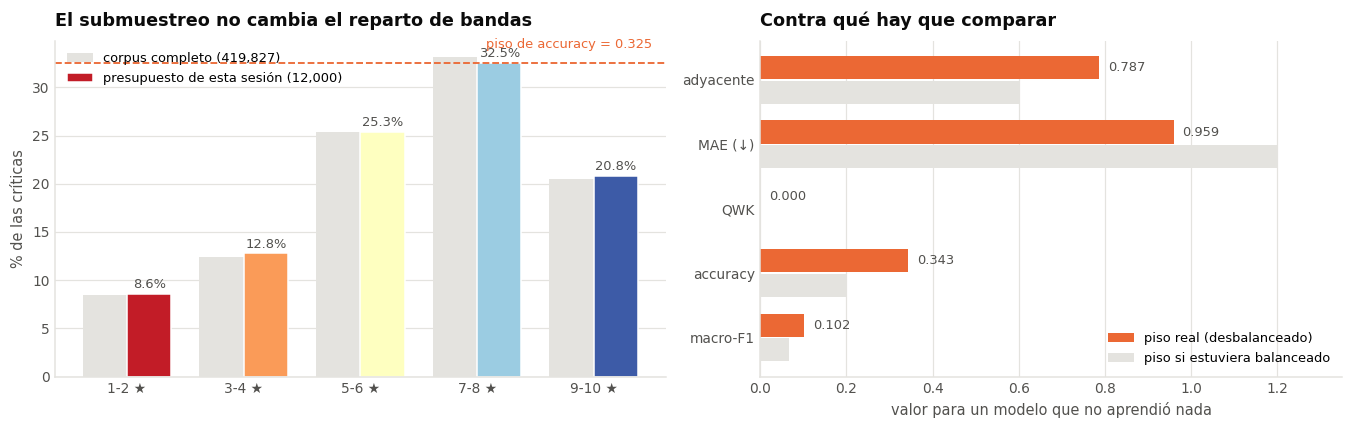

El submuestreo a 12,000 desvía el reparto como mucho 0.66 puntos porcentuales.


In [ ]:
piso = pd.DataFrame({
    "métrica": ["macro-F1", "accuracy", "QWK", "MAE (↓)", "adyacente"],
    "piso B0": [b0["macro_f1"], b0["accuracy"], b0["qwk"], b0["mae"], b0["adyacente"]],
})
piso["si estuviera balanceado"] = [0.0667, 1/N_CLASES, 0.0, 1.20, 0.60]

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12.4, 4.0),
                               gridspec_kw={"width_ratios": [1.05, 1]})

frac_corpus = criticas.y.value_counts(normalize=True).sort_index() * 100
frac_train  = df_train.y.value_counts(normalize=True).sort_index() * 100
x = np.arange(N_CLASES); ancho = 0.38
ax1.bar(x - ancho/2, frac_corpus, ancho, color=MALLA, label=f"corpus completo ({len(criticas):,})")
ax1.bar(x + ancho/2, frac_train, ancho, color=COLOR_BANDA, edgecolor="white",
        label=f"presupuesto de esta sesión ({len(df_train):,})")
for i, v in enumerate(frac_train):
    ax1.text(i + ancho/2, v + 0.6, f"{v:.1f}%", ha="center", fontsize=8.5, color=TINTA_2)
ax1.axhline(frac_train.max(), color=NARANJA, lw=1.2, ls="--")
ax1.text(N_CLASES - 0.5, frac_train.max() + 1.6,
         f"piso de accuracy = {frac_train.max()/100:.3f}", ha="right",
         fontsize=8.5, color=NARANJA)
ax1.set_xticks(x); ax1.set_xticklabels([f"{b} ★" for b in BANDAS])
ax1.set_ylabel("% de las críticas")
ax1.set_title("El submuestreo no cambia el reparto de bandas")
ax1.legend(loc="upper left", fontsize=8.5)
ax1.grid(axis="y"); ax1.set_axisbelow(True); limpiar(ax1)

y = np.arange(len(piso))
ax2.barh(y + 0.19, piso["piso B0"], 0.36, color=NARANJA, label="piso real (desbalanceado)")
ax2.barh(y - 0.19, piso["si estuviera balanceado"], 0.36, color=MALLA,
         label="piso si estuviera balanceado")
for i, v in enumerate(piso["piso B0"]):
    ax2.text(v + 0.02, i + 0.19, f"{v:.3f}", va="center", fontsize=8.5, color=TINTA_2)
ax2.set_yticks(y); ax2.set_yticklabels(piso["métrica"], fontsize=9)
ax2.set_xlim(0, 1.35)
ax2.set_xlabel("valor para un modelo que no aprendió nada")
ax2.set_title("Contra qué hay que comparar")
ax2.legend(loc="lower right", fontsize=8.5)
ax2.grid(axis="x"); ax2.set_axisbelow(True); limpiar(ax2)

plt.tight_layout(); guardar(fig, "01-pisos-y-reparto"); plt.show()

print(f"El submuestreo a {len(df_train):,} desvía el reparto como mucho "
      f"{(frac_corpus - frac_train).abs().max():.2f} puntos porcentuales.")

**Decisión.** Todo se lee contra macro-F1 = 0,102, no contra *accuracy* = 0,343. Y la *accuracy
adyacente* no se usa nunca para decidir si un modelo funciona.

El submuestreo no distorsiona nada: la desviación máxima frente al corpus completo es de 0,66 puntos
porcentuales. Son menos datos, no datos distintos.

### 3.2 El tokenizador de BETO

Un modelo preentrenado viene con su tokenizador atado: si usáramos otro, los índices no
corresponderían a los *embeddings* aprendidos. Así que el vocabulario de BETO es un dato del
problema. Lo que sí podemos hacer es **comprobar que nos sirve** en vez de heredar la elección del
guía.

Miramos dos cosas: la **fertilidad** (cuántos *tokens* genera por palabra, porque si es alta cada
crítica ocupa más sitio y se trunca antes) y la **cobertura** (qué parte del vocabulario del corpus
existe como pieza entera, porque BETO se entrenó con Wikipedia y el argot de la crítica de cine no es
Wikipedia).

In [ ]:
from transformers import AutoTokenizer

tokenizador = AutoTokenizer.from_pretrained(MODELO_BASE)
print(f"vocabulario        : {tokenizador.vocab_size:,} piezas")
print(f"longitud máxima    : {tokenizador.model_max_length} tokens  (techo duro del modelo)")
print(f"entradas al modelo : {tokenizador.model_input_names}\n")

N_SONDA = 3_000
sonda = df_train.sample(min(N_SONDA, len(df_train)), random_state=SEED).reset_index(drop=True)
codif = tokenizador(list(sonda.texto), add_special_tokens=False)["input_ids"]

n_palabras = sonda.texto.str.split().apply(len).values
n_tokens   = np.array([len(c) for c in codif])
fertilidad = n_tokens / np.maximum(n_palabras, 1)
tasa_unk = sum(c.count(tokenizador.unk_token_id) for c in codif) / max(n_tokens.sum(), 1)

print(f"fertilidad media   : {fertilidad.mean():.3f} tokens por palabra")
print(f"tasa de [UNK]      : {tasa_unk:.4%} de los tokens")
print(f"longitud mediana   : {np.median(n_palabras):.0f} palabras → {np.median(n_tokens):.0f} tokens")

config.json:   0%|          | 0.00/648 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/364 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/242k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/480k [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/134 [00:00<?, ?B/s]

vocabulario        : 31,002 piezas
longitud máxima    : 512 tokens  (techo duro del modelo)
entradas al modelo : ['input_ids', 'token_type_ids', 'attention_mask']



[transformers] Token indices sequence length is longer than the specified maximum sequence length for this model (547 > 512). Running this sequence through the model will result in indexing errors


fertilidad media   : 1.330 tokens por palabra
tasa de [UNK]      : 0.4767% de los tokens
longitud mediana   : 191 palabras → 250 tokens


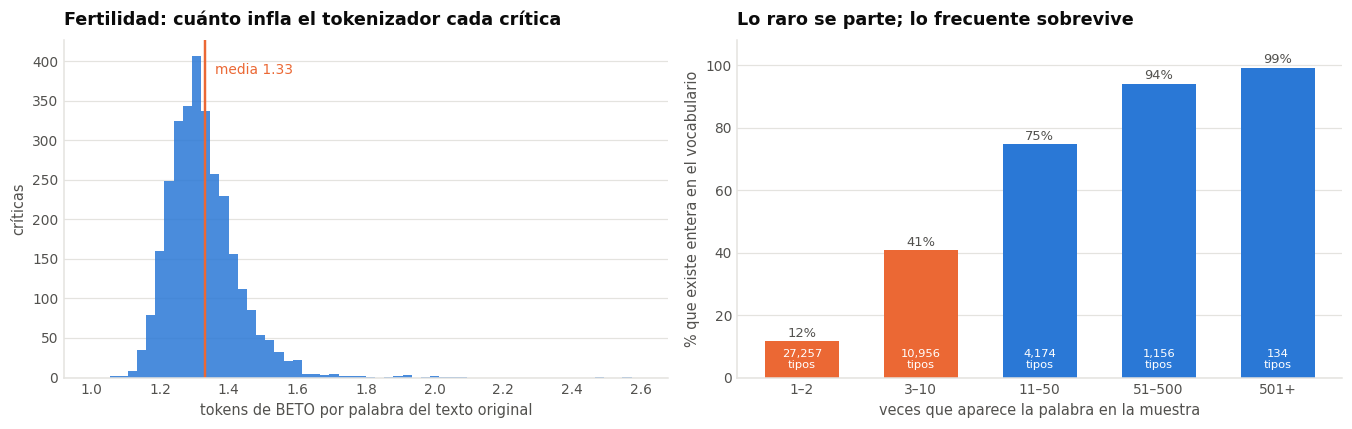

franja  tipos  % entera
   1–2  27257      11.5
  3–10  10956      40.8
 11–50   4174      74.7
51–500   1156      94.0
  501+    134      99.3


In [ ]:
palabras = Counter()
for t in sonda.texto:
    palabras.update(re.findall(r"[a-záéíóúüñ]+", t.lower()))

vocab = tokenizador.get_vocab()
def es_entera(p):
    return p in vocab or p.capitalize() in vocab

franjas = [(1, 2, "1–2"), (3, 10, "3–10"), (11, 50, "11–50"),
           (51, 500, "51–500"), (501, 10**9, "501+")]
cob = []
for lo, hi, etq in franjas:
    grupo = [p for p, c in palabras.items() if lo <= c <= hi]
    if grupo:
        cob.append({"franja": etq, "tipos": len(grupo),
                    "% entera": 100 * np.mean([es_entera(p) for p in grupo])})
cob = pd.DataFrame(cob)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12.4, 4.0))

ax1.hist(fertilidad, bins=60, range=(1.0, 2.6), color=AZUL, alpha=.85)
ax1.axvline(fertilidad.mean(), color=NARANJA, lw=1.6)
ax1.text(fertilidad.mean() + .03, ax1.get_ylim()[1] * .9,
         f"media {fertilidad.mean():.2f}", color=NARANJA, fontsize=9)
ax1.set_xlabel("tokens de BETO por palabra del texto original")
ax1.set_ylabel("críticas")
ax1.set_title("Fertilidad: cuánto infla el tokenizador cada crítica")
ax1.grid(axis="y"); ax1.set_axisbelow(True); limpiar(ax1)

colores = [NARANJA if i < 2 else AZUL for i in range(len(cob))]
ax2.bar(cob.franja, cob["% entera"], color=colores, width=.62)
for i, (pct, n_tipos) in enumerate(zip(cob["% entera"], cob["tipos"])):
    ax2.text(i, pct + 1.5, f"{pct:.0f}%", ha="center", fontsize=8.5, color=TINTA_2)
    ax2.text(i, 3, f"{n_tipos:,}\ntipos", ha="center", fontsize=7.5, color="white")
ax2.set_ylim(0, 108)
ax2.set_xlabel("veces que aparece la palabra en la muestra")
ax2.set_ylabel("% que existe entera en el vocabulario")
ax2.set_title("Lo raro se parte; lo frecuente sobrevive")
ax2.grid(axis="y"); ax2.set_axisbelow(True); limpiar(ax2)

plt.tight_layout(); guardar(fig, "02-tokenizador-beto"); plt.show()
print(cob.to_string(index=False, float_format=lambda v: f"{v:.1f}"))

**Decisión: BETO se queda.** La tasa de `[UNK]` es del 0,48% y la cobertura se comporta como debe:
las palabras frecuentes existen enteras el 99,3% de las veces y las raras sólo el 11,5%.

La cifra a retener es la **fertilidad: 1,33 tokens por palabra**. La crítica mediana tiene 191
palabras y ocupa **250 tokens**. Es el primer peaje del preentrenamiento: se hereda el conocimiento,
pero también el vocabulario de otro dominio, y eso empeora el truncamiento. §3.4 lo cuantifica.

### 3.3 ¿Llegan enteras las palabras que deciden la clase?

La cobertura media no es lo que importa; importa la de las palabras que deciden la banda. Las
identificamos con el estadístico de log-odds de Monroe *et al.* (2008) —el mismo de la Sesión 2—
comparando las bandas bajas con las altas, y miramos cómo las parte BETO.

Aparte miramos los **marcadores funcionales**: `no`, `pero`, `sin`, `nunca`, `aunque`, `tampoco`. De
ellos depende la composicionalidad, y son los que va a manipular el test de §7.2.

In [ ]:
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
from sklearn.linear_model import LogisticRegression

MARCADORES = ["no", "pero", "sin", "nunca", "aunque", "tampoco", "nada", "poco",
              "demasiado", "sino", "salvo", "apenas"]

def log_odds_z(textos_a, textos_b, min_df=25):
    """z del log-odds con prior de Dirichlet informativo. z>0 = propio de A (bandas bajas)."""
    vec = CountVectorizer(min_df=min_df, max_df=.6, token_pattern=r"(?u)\b[a-záéíóúüñ]{2,}\b")
    X = vec.fit_transform(list(textos_a) + list(textos_b))
    na = len(textos_a)
    ya = np.asarray(X[:na].sum(axis=0)).ravel().astype(float)
    yb = np.asarray(X[na:].sum(axis=0)).ravel().astype(float)
    total = ya + yb
    alfa = total / total.sum() * 500.0
    a0 = alfa.sum()
    def logit(y, a):
        return np.log((y + a) / (y.sum() + a0 - y - a))
    delta = logit(ya, alfa) - logit(yb, alfa)
    var = 1.0 / (ya + alfa) + 1.0 / (yb + alfa)
    return pd.DataFrame({"termino": vec.get_feature_names_out(),
                         "z": delta / np.sqrt(var), "freq": total})

bajas = df_train[df_train.y <= 1].texto
altas = df_train[df_train.y >= 3].texto
disc = log_odds_z(bajas, altas).sort_values("z")

def n_piezas(palabra):
    return len(tokenizador.tokenize(palabra))

TOP = 40
extremos = pd.concat([disc.head(TOP), disc.tail(TOP)])
extremos["piezas"] = extremos.termino.map(n_piezas)

marc = pd.DataFrame({"termino": MARCADORES})
marc["piezas"] = marc.termino.map(n_piezas)

generales = disc.sample(min(400, len(disc)), random_state=SEED).copy()
generales["piezas"] = generales.termino.map(n_piezas)

print("Característicos de las bandas ALTAS (z < 0):")
print("   " + ", ".join(f"{t}({n_piezas(t)})" for t in disc.head(14).termino))
print("\nCaracterísticos de las bandas BAJAS (z > 0):")
print("   " + ", ".join(f"{t}({n_piezas(t)})" for t in disc.tail(14).termino))
print("\n(entre paréntesis, en cuántas piezas lo parte BETO)")
print(f"\nMarcadores funcionales partidos: {int((marc.piezas > 1).sum())} de {len(marc)}")

Característicos de las bandas ALTAS (z < 0):
   gran(1), vida(1), sus(1), amor(1), mejores(1), excelente(1), obra(1), cada(1), también(1), forma(1), sobre(1), nos(1), maestra(1), duda(1)

Característicos de las bandas BAJAS (z > 0):
   único(1), gracia(1), siquiera(1), porque(1), cosa(1), qué(1), me(1), aburrida(1), si(1), peor(1), mal(1), mala(1), nada(1), ni(1)

(entre paréntesis, en cuántas piezas lo parte BETO)

Marcadores funcionales partidos: 0 de 12


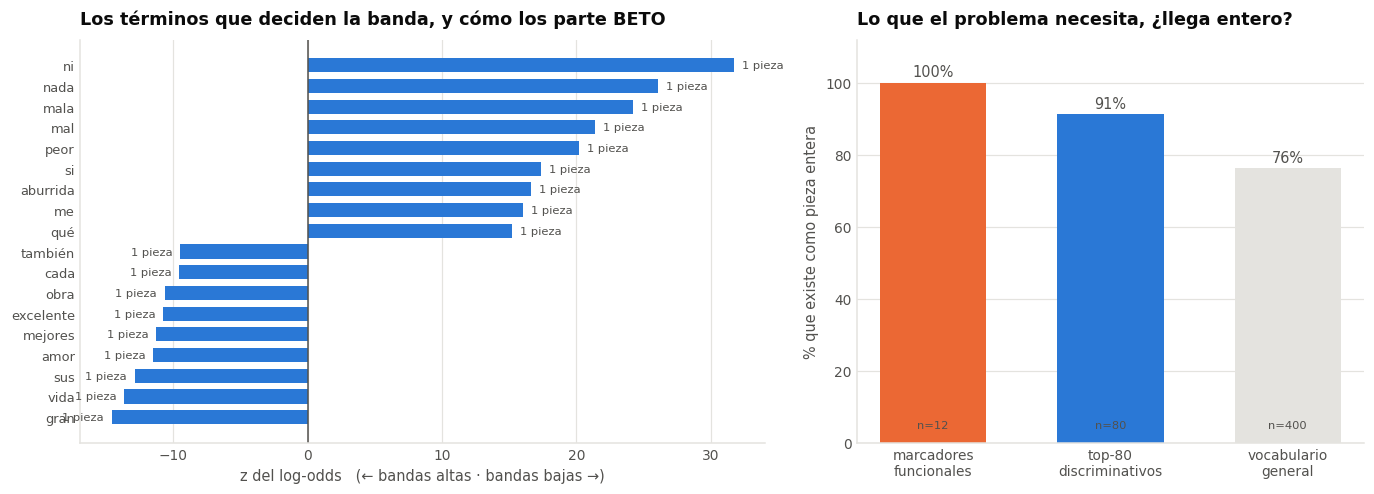

marcadores funcionales enteros : 100%
top-80 discriminativos enteros : 91%


In [ ]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12.6, 4.6),
                               gridspec_kw={"width_ratios": [1.35, 1]})

muestra = pd.concat([disc.head(9), disc.tail(9)]).copy()
muestra["piezas"] = muestra.termino.map(n_piezas)
orden = muestra.sort_values("z")
y = np.arange(len(orden))
col = [NARANJA if p > 1 else AZUL for p in orden.piezas]
ax1.barh(y, orden.z, color=col, height=.68)
for i, (z_i, pz) in enumerate(zip(orden["z"], orden["piezas"])):
    lado = 1 if z_i > 0 else -1
    ax1.text(z_i + lado * 0.6, i, f"{pz} pieza" + ("s" if pz > 1 else ""),
             va="center", ha="left" if lado > 0 else "right", fontsize=7.5, color=TINTA_2)
ax1.set_yticks(y); ax1.set_yticklabels(orden.termino, fontsize=8.5)
ax1.axvline(0, color=TINTA_2, lw=1.0)
ax1.set_xlabel("z del log-odds   (← bandas altas · bandas bajas →)")
ax1.set_title("Los términos que deciden la banda, y cómo los parte BETO")
ax1.grid(axis="x"); ax1.set_axisbelow(True); limpiar(ax1)

grupos = [
    ("marcadores\nfuncionales", 100 * float((marc.piezas == 1).mean()), len(marc)),
    ("top-80\ndiscriminativos", 100 * float((extremos.piezas == 1).mean()), len(extremos)),
    ("vocabulario\ngeneral", 100 * float((generales.piezas == 1).mean()), len(generales)),
]
ax2.bar([g[0] for g in grupos], [g[1] for g in grupos],
        color=[NARANJA, AZUL, MALLA], width=.6)
for i, (n, v, k) in enumerate(grupos):
    ax2.text(i, v + 1.8, f"{v:.0f}%", ha="center", fontsize=9.5, color=TINTA_2)
    ax2.text(i, 4, f"n={k}", ha="center", fontsize=7.5, color=TINTA_2)
ax2.set_ylim(0, 112)
ax2.set_ylabel("% que existe como pieza entera")
ax2.set_title("Lo que el problema necesita, ¿llega entero?")
ax2.grid(axis="y"); ax2.set_axisbelow(True); limpiar(ax2)

plt.tight_layout(); guardar(fig, "03-fragmentacion-terminos"); plt.show()

PCT_MARCADORES_ENTEROS = 100 * float((marc.piezas == 1).mean())
PCT_DISC_ENTEROS = 100 * float((extremos.piezas == 1).mean())
print(f"marcadores funcionales enteros : {PCT_MARCADORES_ENTEROS:.0f}%")
print(f"top-80 discriminativos enteros : {PCT_DISC_ENTEROS:.0f}%")

**Decisión: no hace falta ampliar el vocabulario**, que era la alternativa cara.

Los **12 marcadores funcionales llegan enteros**, y era lo importante: BETO tiene la materia prima
para leer la negación, que es justo lo que pone a prueba H1. Si falla en §7, no será por el
tokenizador. De los 80 términos más discriminativos llegan enteros el **91%**; lo que se parte es el
argot evaluativo, que Wikipedia no tiene.

La lista en sí ya dice algo: las bandas altas las separan *gran, amor, obra, maestra, excelente* y
las bajas *ni, nada, mala, peor, aburrida*. Vocabulario evaluativo puro, que es exactamente lo que
una bolsa de palabras aprovecha bien.

### 3.4 Cuánto texto le cabe

El primer límite que confesó la Sesión 2 fue el truncamiento. BETO admite hasta 512 posiciones, el
doble de lo que usamos entonces, pero es un **techo duro**: la tabla de posiciones tiene 512 filas y
no se puede pedir más sin reentrenarla.

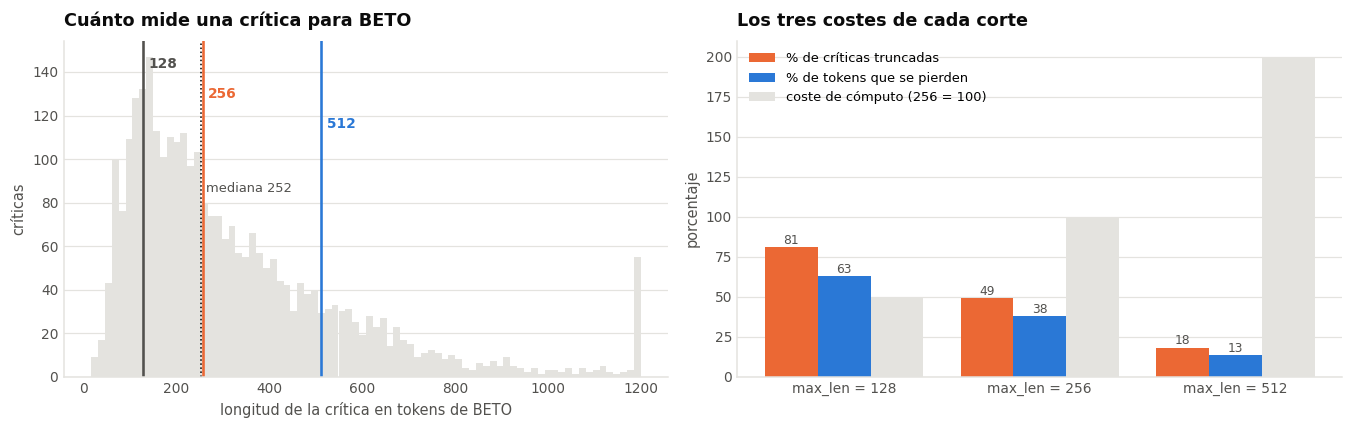

 max_len  % críticas truncadas  % tokens perdidos  coste relativo
     128                  81.1               63.1             0.5
     256                  49.0               37.9             1.0
     512                  18.1               13.3             2.0


In [ ]:
CORTES = [128, 256, 512]
largos = n_tokens + 2

costes = pd.DataFrame([
    {"max_len": c,
     "% críticas truncadas": 100 * float(np.mean(largos > c)),
     "% tokens perdidos": 100 * float(np.sum(np.maximum(largos - c, 0)) / largos.sum()),
     "coste relativo": c / 256}
    for c in CORTES])

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12.4, 4.0))

ax1.hist(np.clip(largos, 0, 1200), bins=80, color=MALLA)
for c, colr in zip(CORTES, [TINTA_2, NARANJA, AZUL]):
    ax1.axvline(c, color=colr, lw=1.7)
    ax1.text(c + 12, ax1.get_ylim()[1] * (.92 - .09 * CORTES.index(c)),
             f"{c}", color=colr, fontsize=9, fontweight="bold")
ax1.axvline(np.median(largos), color="black", lw=1.0, ls=":")
ax1.text(np.median(largos) + 12, ax1.get_ylim()[1] * .55,
         f"mediana {np.median(largos):.0f}", fontsize=8.5, color=TINTA_2)
ax1.set_xlabel("longitud de la crítica en tokens de BETO")
ax1.set_ylabel("críticas")
ax1.set_title("Cuánto mide una crítica para BETO")
ax1.grid(axis="y"); ax1.set_axisbelow(True); limpiar(ax1)

x = np.arange(len(CORTES)); ancho = .27
ax2.bar(x - ancho, costes["% críticas truncadas"], ancho, color=NARANJA,
        label="% de críticas truncadas")
ax2.bar(x, costes["% tokens perdidos"], ancho, color=AZUL,
        label="% de tokens que se pierden")
ax2.bar(x + ancho, costes["coste relativo"] * 100, ancho, color=MALLA,
        label="coste de cómputo (256 = 100)")
for i, (trunc, perd) in enumerate(zip(costes["% críticas truncadas"],
                                      costes["% tokens perdidos"])):
    ax2.text(i - ancho, trunc + 2, f"{trunc:.0f}", ha="center", fontsize=8, color=TINTA_2)
    ax2.text(i, perd + 2, f"{perd:.0f}", ha="center", fontsize=8, color=TINTA_2)
ax2.set_xticks(x); ax2.set_xticklabels([f"max_len = {c}" for c in CORTES])
ax2.set_ylabel("porcentaje")
ax2.set_title("Los tres costes de cada corte")
ax2.legend(fontsize=8.5, loc="upper left")
ax2.grid(axis="y"); ax2.set_axisbelow(True); limpiar(ax2)

plt.tight_layout(); guardar(fig, "04-longitud-y-cortes"); plt.show()
print(costes.to_string(index=False, float_format=lambda v: f"{v:.1f}"))

**Decisión: `max_len = 256`** en las corridas principales, por continuidad con la Sesión 2, y **una
ablación 128 / 256 / 512 en §6.2**, que es el contraste de H4.

Los números son peores de lo que parecían: a 256 se trunca el **49% de las críticas** y se pierde el
**37,9% de los tokens**, y a 128 se pierde el 63,1%. Y **ni siquiera 512 alcanza**: ahí todavía se
trunca el 18,1%. Un modelo con ventana de 512 no resuelve este corpus, lo recorta un poco menos.

### 3.5 Qué trae puesto: la geometría antes de entrenar

Esta es la figura central del EDA. Pasamos críticas por BETO **recién descargado**, sin ajustar un
solo peso, y miramos dónde las coloca. Si el preentrenamiento trae algo aprovechable, las críticas de
`1-2` tienen que caer en otra zona que las de `9-10` **sin que nadie le haya dicho nunca qué es una
banda**. Y si la escala es un orden, la similitud entre centroides tiene que decaer con la distancia
ordinal.

La Sesión 2 midió esa misma propiedad sobre centroides TF-IDF y le salió r = −0,953. Eso da una vara:
¿trae BETO, sin entrenar, mejor geometría que contar palabras?

Medimos las dos formas de resumir una crítica en un vector, porque la diferencia importa: el `[CLS]`
pasa por un *pooler* entrenado para otra tarea, mientras que el promedio de los estados ocultos no
depende de esa cabeza.

In [ ]:
import torch.nn.functional as F
from transformers import AutoModel

LARGO_SONDA = 256
N_GEOM = 2_500
geom = df_val.sample(min(N_GEOM, len(df_val)), random_state=SEED).reset_index(drop=True)

@torch.no_grad()
def representar(textos, modelo, tok, largo=LARGO_SONDA, lote=32):
    """Devuelve (cls, media) del modelo, en float32 y en CPU."""
    modelo.eval()
    cls_l, med_l = [], []
    for i in range(0, len(textos), lote):
        b = tok(list(textos[i:i + lote]), max_length=largo, truncation=True,
                padding="max_length", return_tensors="pt").to(DEVICE)
        h = modelo(**b).last_hidden_state
        m = b["attention_mask"].unsqueeze(-1).float()
        cls_l.append(h[:, 0].float().cpu())
        med_l.append(((h * m).sum(1) / m.sum(1).clamp(min=1)).float().cpu())
    return torch.cat(cls_l).numpy(), torch.cat(med_l).numpy()

with medir("§3.5 representaciones sin entrenar"):
    base = AutoModel.from_pretrained(MODELO_BASE).to(DEVICE)
    E_cls, E_med = representar(geom.texto.values, base, tokenizador)
    del base; torch.cuda.empty_cache()

def geometria(E, etiquetas):
    C = np.stack([E[etiquetas == k].mean(0) for k in range(N_CLASES)])
    Cn = C / np.linalg.norm(C, axis=1, keepdims=True)
    S = Cn @ Cn.T
    iu = np.triu_indices(N_CLASES, k=1)
    d = np.abs(iu[0] - iu[1]).astype(float)
    return S, d, S[iu], float(np.corrcoef(S[iu], d)[0, 1])

S_cls, dist_ord, sim_cls, R_CLS = geometria(E_cls, geom.y.values)
S_med, _,        sim_med, R_MED = geometria(E_med, geom.y.values)

print(f"representaciones: {E_cls.shape}\n")
print("correlación similitud ↔ distancia ordinal")
print(f"   [CLS] sin ajustar        : r = {R_CLS:+.3f}")
print(f"   media de estados ocultos : r = {R_MED:+.3f}")
print(f"   (referencia Sesión 2, centroides TF-IDF: r = -0.953)")

MEJOR_AGREG = "media" if abs(R_MED) > abs(R_CLS) else "cls"
E_SONDA = E_med if MEJOR_AGREG == "media" else E_cls
S_SONDA = S_med if MEJOR_AGREG == "media" else S_cls
R_SONDA = R_MED if MEJOR_AGREG == "media" else R_CLS
print(f"\nSe usa la agregación '{MEJOR_AGREG}' para el resto del EDA.")

pytorch_model.bin: reconstructing file:   0%|          |  0.00B /  440MB            

pytorch_model.bin: downloading bytes:           |  0.00B            

model.safetensors: reconstructing file:   0%|          |  0.00B /  440MB            

model.safetensors: downloading bytes:           |  0.00B            

Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

[transformers] BertModel LOAD REPORT from: dccuchile/bert-base-spanish-wwm-cased
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.predictions.decoder.bias               | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.predictions.decoder.weight             | UNEXPECTED | 
pooler.dense.weight                        | MISSING    | 
pooler.dense.bias                          | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


   ⏱  §3.5 representaciones sin entrenar: 1.2 min   (acumulado 1.2 min)
representaciones: (2500, 768)

correlación similitud ↔ distancia ordinal
   [CLS] sin ajustar        : r = -0.783
   media de estados ocultos : r = -0.938
   (referencia Sesión 2, centroides TF-IDF: r = -0.953)

Se usa la agregación 'media' para el resto del EDA.


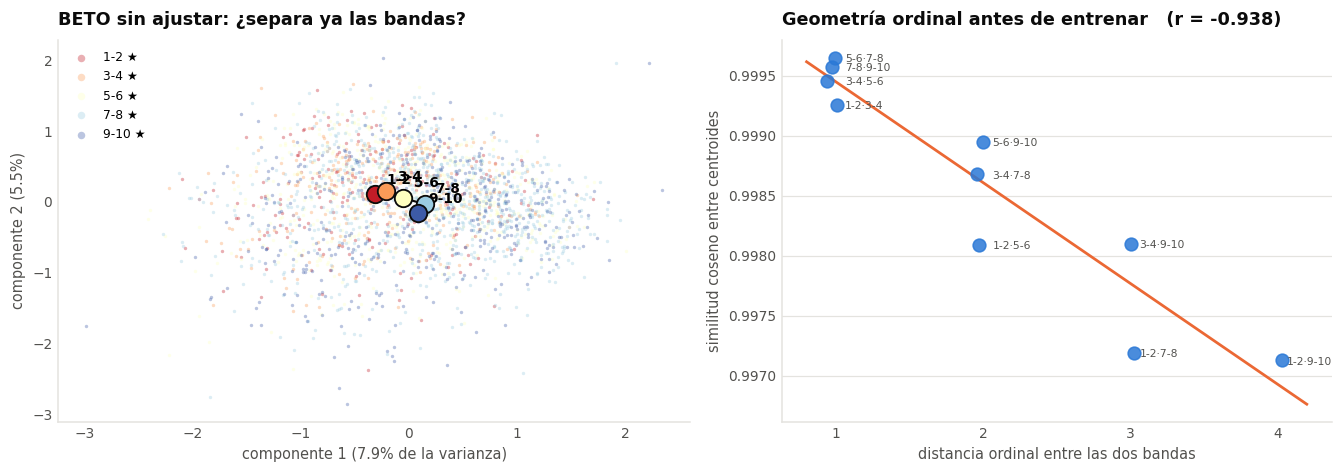

In [ ]:
from sklearn.decomposition import PCA

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12.4, 4.4),
                               gridspec_kw={"width_ratios": [1.15, 1]})

P = PCA(n_components=2, random_state=SEED).fit(E_SONDA)
Z = P.transform(E_SONDA)
for k in range(N_CLASES):
    sel = geom.y.values == k
    ax1.scatter(Z[sel, 0], Z[sel, 1], s=5, alpha=.35, color=COLOR_BANDA[k],
                label=f"{BANDAS[k]} ★", linewidths=0)
Zc = P.transform(np.stack([E_SONDA[geom.y.values == k].mean(0) for k in range(N_CLASES)]))
ax1.plot(Zc[:, 0], Zc[:, 1], color=TINTA, lw=1.4, zorder=5)
for k in range(N_CLASES):
    ax1.scatter(*Zc[k], s=130, color=COLOR_BANDA[k], edgecolor=TINTA, zorder=6, linewidths=1.2)
    ax1.annotate(BANDAS[k], Zc[k], textcoords="offset points", xytext=(7, 7),
                 fontsize=9, fontweight="bold")
ax1.set_xlabel(f"componente 1 ({P.explained_variance_ratio_[0]:.1%} de la varianza)")
ax1.set_ylabel(f"componente 2 ({P.explained_variance_ratio_[1]:.1%})")
ax1.set_title("BETO sin ajustar: ¿separa ya las bandas?")
ax1.legend(fontsize=8, markerscale=2.2, loc="best")
limpiar(ax1)

iu = np.triu_indices(N_CLASES, k=1)
ax2.scatter(dist_ord + np.random.default_rng(SEED).normal(0, .03, len(dist_ord)),
            S_SONDA[iu], s=70, color=AZUL, alpha=.85, zorder=3)
coef = np.polyfit(dist_ord, S_SONDA[iu], 1)
xs = np.linspace(.8, 4.2, 20)
ax2.plot(xs, np.polyval(coef, xs), color=NARANJA, lw=1.8)
for (a, b), s in zip(zip(*iu), S_SONDA[iu]):
    ax2.annotate(f"{BANDAS[a]}·{BANDAS[b]}", (abs(a - b), s),
                 textcoords="offset points", xytext=(6, -3), fontsize=7, color=TINTA_2)
ax2.set_xticks([1, 2, 3, 4])
ax2.set_xlabel("distancia ordinal entre las dos bandas")
ax2.set_ylabel("similitud coseno entre centroides")
ax2.set_title(f"Geometría ordinal antes de entrenar   (r = {R_SONDA:+.3f})")
ax2.grid(axis="y"); ax2.set_axisbelow(True); limpiar(ax2)

plt.tight_layout(); guardar(fig, "05-geometria-sin-entrenar"); plt.show()

**Decisión: se usa el promedio de estados ocultos.** Medirlo tenía premio: la media da **r = −0,938**
y el `[CLS]` sólo **−0,783**, y el guía usa por defecto el `[CLS]`, que aquí es el peor de los dos.

Lo que enseña la figura es más interesante que la decisión. Las nubes de las cinco bandas se solapan
mucho —BETO sin ajustar **no separa** las bandas, y era de esperar—, pero los centroides no están
puestos al azar: se ordenan a lo largo de una dirección, con una correlación casi tan buena como la
del TF-IDF de la Sesión 2 (−0,953). **La escala ya está insinuada en el espacio antes de entrenar.**

### 3.6 Cuánto se saca sin entrenar nada

Lo anterior es cualitativo. Esto lo convierte en una cifra: una regresión logística sobre las
representaciones congeladas. Es una cota inferior de lo que puede dar la modalidad *featurizer*,
medida en segundos, y fija la expectativa de §5.3 antes de gastar GPU en ella.

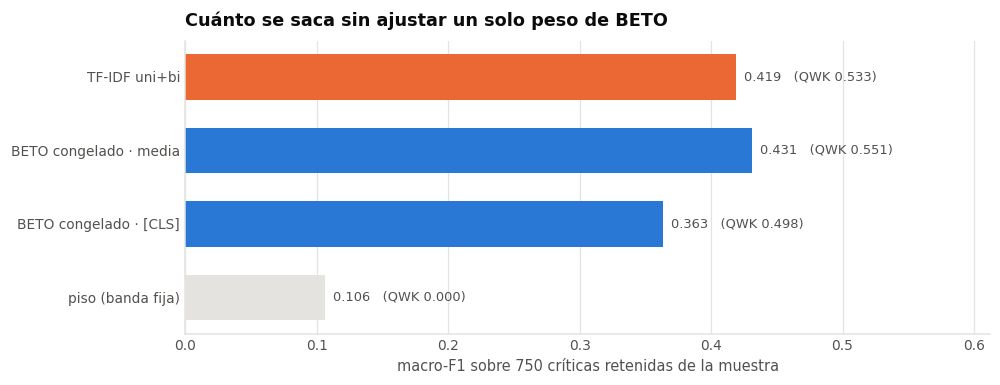

        representación  macro-F1    QWK
     piso (banda fija)    0.1062 0.0000
BETO congelado · [CLS]    0.3633 0.4984
BETO congelado · media    0.4311 0.5515
         TF-IDF uni+bi    0.4188 0.5331

Brecha sonda congelada ↔ TF-IDF en esta muestra: +0.0124 de macro-F1


In [ ]:
n_ajuste = int(.7 * len(geom))
idx = np.arange(len(geom))
tr_s, ev_s = idx[:n_ajuste], idx[n_ajuste:]
y_s = geom.y.values

def sonda_lineal(E, etiqueta):
    clf = LogisticRegression(max_iter=3000, C=1.0, class_weight="balanced",
                             random_state=SEED).fit(E[tr_s], y_s[tr_s])
    p = clf.predict(E[ev_s])
    return {"representación": etiqueta,
            "macro-F1": f1_score(y_s[ev_s], p, average="macro"),
            "QWK": cohen_kappa_score(y_s[ev_s], p, weights="quadratic",
                                     labels=list(range(N_CLASES)))}

tf = TfidfVectorizer(min_df=3, max_df=.5, sublinear_tf=True, ngram_range=(1, 2))
Xtf = tf.fit_transform(geom.texto.values[tr_s])
clf_tf = LogisticRegression(max_iter=2000, C=4.0, class_weight="balanced",
                            random_state=SEED).fit(Xtf, y_s[tr_s])
p_tf = clf_tf.predict(tf.transform(geom.texto.values[ev_s]))

sondas = pd.DataFrame([
    {"representación": "piso (banda fija)",
     "macro-F1": f1_score(y_s[ev_s], np.full(len(ev_s), CONSTANTE), average="macro"),
     "QWK": 0.0},
    sonda_lineal(E_cls, "BETO congelado · [CLS]"),
    sonda_lineal(E_med, "BETO congelado · media"),
    {"representación": "TF-IDF uni+bi",
     "macro-F1": f1_score(y_s[ev_s], p_tf, average="macro"),
     "QWK": cohen_kappa_score(y_s[ev_s], p_tf, weights="quadratic",
                              labels=list(range(N_CLASES)))},
])

fig, ax = plt.subplots(figsize=(9.2, 3.6))
y = np.arange(len(sondas))
ax.barh(y, sondas["macro-F1"], color=[MALLA, AZUL, AZUL, NARANJA], height=.62)
for i, (f1_i, qwk_i) in enumerate(zip(sondas["macro-F1"], sondas["QWK"])):
    ax.text(f1_i + .006, i, f"{f1_i:.3f}   (QWK {qwk_i:.3f})", va="center",
            fontsize=8.5, color=TINTA_2)
ax.set_yticks(y); ax.set_yticklabels(sondas["representación"], fontsize=9)
ax.set_xlim(0, sondas["macro-F1"].max() * 1.42)
ax.set_xlabel(f"macro-F1 sobre {len(ev_s)} críticas retenidas de la muestra")
ax.set_title("Cuánto se saca sin ajustar un solo peso de BETO")
ax.grid(axis="x"); ax.set_axisbelow(True); limpiar(ax)
plt.tight_layout(); guardar(fig, "06-sonda-congelada"); plt.show()

print(sondas.to_string(index=False, float_format=lambda v: f"{v:.4f}"))
SONDA_CONGELADA = float(sondas.loc[sondas["representación"] == "BETO congelado · media",
                                   "macro-F1"].iloc[0])
SONDA_TFIDF = float(sondas.loc[sondas["representación"] == "TF-IDF uni+bi",
                               "macro-F1"].iloc[0])
print(f"\nBrecha sonda congelada ↔ TF-IDF en esta muestra: "
      f"{SONDA_CONGELADA - SONDA_TFIDF:+.4f} de macro-F1")

**Resultado inesperado.** Sobre la misma muestra, **BETO congelado saca 0,431 y el TF-IDF con
bigramas 0,419**: el preentrenado gana **sin haber entrenado nada**, sólo con una regresión logística
encima de sus vectores.

Dos avisos. La muestra son 750 críticas, así que +0,012 es poco y el TF-IDF está en desventaja porque
con tan pocos documentos no construye un vocabulario decente — en §5.1, con 12.000, el orden se
invierte. Y el `[CLS]`, que es lo que usa el guía, se queda en 0,363.

Aun así fija la expectativa: las representaciones congeladas ya sirven, y el trabajo del
*fine-tuning* será recorrer la distancia entre "servir" y "ganar".

### 3.7 Lo que cuesta cada modalidad

Última decisión del EDA, y es de presupuesto. Contamos los parámetros entrenables de cada
configuración instanciándolas, que es gratis.

Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

[transformers] BertForSequenceClassification LOAD REPORT from: dccuchile/bert-base-spanish-wwm-cased
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.predictions.decoder.bias               | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.predictions.decoder.weight             | UNEXPECTED | 
bert.pooler.dense.bias                     | MISSING    | 
classifier.weight                          | MISSING    | 
classifier.bias                            | MISSING    | 
bert.pooler.dense.weight                   | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	

Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

[transformers] BertForSequenceClassification LOAD REPORT from: dccuchile/bert-base-spanish-wwm-cased
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.predictions.decoder.bias               | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.predictions.decoder.weight             | UNEXPECTED | 
bert.pooler.dense.bias                     | MISSING    | 
classifier.weight                          | MISSING    | 
classifier.bias                            | MISSING    | 
bert.pooler.dense.weight                   | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	

Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

[transformers] BertForSequenceClassification LOAD REPORT from: dccuchile/bert-base-spanish-wwm-cased
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.predictions.decoder.bias               | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.predictions.decoder.weight             | UNEXPECTED | 
bert.pooler.dense.bias                     | MISSING    | 
classifier.weight                          | MISSING    | 
classifier.bias                            | MISSING    | 
bert.pooler.dense.weight                   | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	

Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

[transformers] BertForSequenceClassification LOAD REPORT from: dccuchile/bert-base-spanish-wwm-cased
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.predictions.decoder.bias               | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.predictions.decoder.weight             | UNEXPECTED | 
bert.pooler.dense.bias                     | MISSING    | 
classifier.weight                          | MISSING    | 
classifier.bias                            | MISSING    | 
bert.pooler.dense.weight                   | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	

Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

[transformers] BertForSequenceClassification LOAD REPORT from: dccuchile/bert-base-spanish-wwm-cased
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.predictions.decoder.bias               | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.predictions.decoder.weight             | UNEXPECTED | 
bert.pooler.dense.bias                     | MISSING    | 
classifier.weight                          | MISSING    | 
classifier.bias                            | MISSING    | 
bert.pooler.dense.weight                   | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	

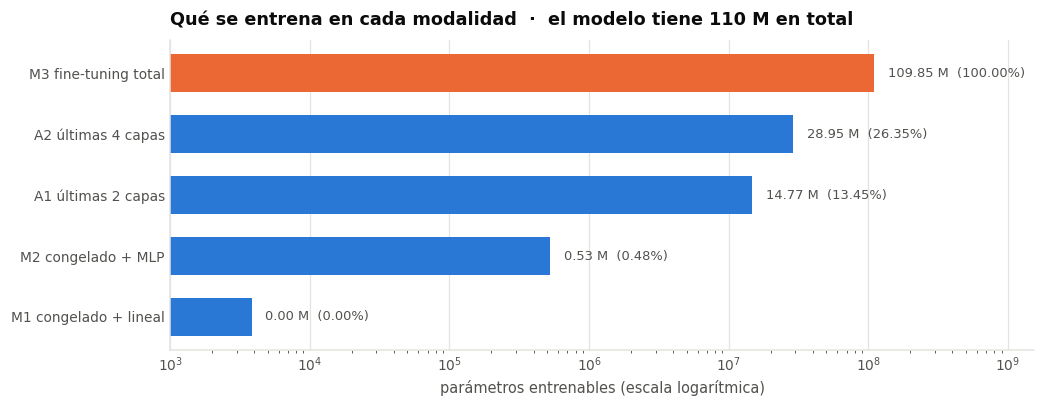

             variante  entrenables     total  % entrenable
M1 congelado + lineal         3845 109854725          0.00
   M2 congelado + MLP       526341 110377221          0.48
   A1 últimas 2 capas     14770181 109854725         13.45
   A2 últimas 4 capas     28945925 109854725         26.35
 M3 fine-tuning total    109854725 109854725        100.00


In [ ]:
from transformers import AutoModelForSequenceClassification
import torch.nn as nn

def construir(modo, n_clases=N_CLASES, ckpt=None, cabeza_mlp=False, capas_libres=None):
    """modo: 'congelado' | 'parcial' (últimas capas_libres capas) | 'completo'."""
    m = AutoModelForSequenceClassification.from_pretrained(
        ckpt or MODELO_BASE, num_labels=n_clases)
    if cabeza_mlp:
        d = m.config.hidden_size
        m.classifier = nn.Sequential(
            nn.Linear(d, 512), nn.ReLU(), nn.Dropout(0.2),
            nn.Linear(512, 256), nn.ReLU(), nn.Dropout(0.2),
            nn.Linear(256, n_clases),
        )
    if modo in ("congelado", "parcial"):
        for p in m.base_model.parameters():
            p.requires_grad = False
        if modo == "parcial":
            capas = m.base_model.encoder.layer
            for capa in capas[len(capas) - capas_libres:]:
                for p in capa.parameters():
                    p.requires_grad = True
            if getattr(m.base_model, "pooler", None) is not None:
                for p in m.base_model.pooler.parameters():
                    p.requires_grad = True
    return m

VARIANTES = [
    ("M1 congelado + lineal", dict(modo="congelado")),
    ("M2 congelado + MLP",    dict(modo="congelado", cabeza_mlp=True)),
    ("A1 últimas 2 capas",    dict(modo="parcial", capas_libres=2)),
    ("A2 últimas 4 capas",    dict(modo="parcial", capas_libres=4)),
    ("M3 fine-tuning total",  dict(modo="completo")),
]

filas = []
for nombre, kw in VARIANTES:
    m = construir(**kw)
    ent = sum(p.numel() for p in m.parameters() if p.requires_grad)
    tot = sum(p.numel() for p in m.parameters())
    filas.append({"variante": nombre, "entrenables": ent, "total": tot,
                  "% entrenable": 100 * ent / tot})
    del m
costo = pd.DataFrame(filas)

fig, ax = plt.subplots(figsize=(9.6, 3.8))
ax.barh(np.arange(len(costo)), costo.entrenables, color=[AZUL] * 4 + [NARANJA], height=.62)
ax.set_xscale("log")
for i, (e, pct) in enumerate(zip(costo["entrenables"], costo["% entrenable"])):
    ax.text(e * 1.25, i, f"{e/1e6:.2f} M  ({pct:.2f}%)", va="center",
            fontsize=8.5, color=TINTA_2)
ax.set_yticks(np.arange(len(costo))); ax.set_yticklabels(costo.variante, fontsize=9)
ax.set_xlim(1e3, costo.entrenables.max() * 14)
ax.set_xlabel("parámetros entrenables (escala logarítmica)")
ax.set_title(f"Qué se entrena en cada modalidad  ·  el modelo tiene "
             f"{costo.total.iloc[0]/1e6:.0f} M en total")
ax.grid(axis="x"); ax.set_axisbelow(True); limpiar(ax)
plt.tight_layout(); guardar(fig, "07-parametros-entrenables"); plt.show()
print(costo.to_string(index=False, float_format=lambda v: f"{v:,.2f}"))

**Decisión: las cinco entran, de menor a mayor coste**, para que si Colab corta la sesión lo hecho
sea lo más informativo por minuto.

El contraste es lo que hace atractiva la pregunta de H5: M1 entrena **3.845 parámetros de 110
millones** y el *fine-tuning* completo los mueve todos. Cuatro órdenes de magnitud entre los
extremos.

### 3.8 Las predicciones, escritas antes de entrenar

Convención que traemos de la Sesión 2, donde nos obligó a reportar tres predicciones fallidas en vez
de reinterpretarlas: **las predicciones se derivan por código de lo medido**, no se eligen a mano
después. Las tres salen de la geometría de §3.5, y ponen a prueba si el espacio que trae puesto el
preentrenamiento anticipa la *forma* del error del modelo ya ajustado.

In [ ]:
iu = np.triu_indices(N_CLASES, k=1)
pares = list(zip(iu[0], iu[1]))
sims = S_SONDA[iu]

# P1 — el par más confundido será el de centroides más parecidos.
PRED_PAR = pares[int(np.argmax(sims))]
# P2 — la banda con peor F1 será la más "rodeada" por el resto.
cercania = np.array([np.mean([S_SONDA[k, j] for j in range(N_CLASES) if j != k])
                     for k in range(N_CLASES)])
PRED_PEOR = int(np.argmax(cercania))
# P3 — la similitud predecirá la confusión real con rho >= 0.50.
PRED_RHO_MIN = 0.50

print("Predicciones registradas antes de entrenar (§8.2 las contrasta):")
print(f"  P1 · par más confundido : {BANDAS[PRED_PAR[0]]} ↔ {BANDAS[PRED_PAR[1]]}")
print(f"  P2 · banda con peor F1  : {BANDAS[PRED_PEOR]}")
print(f"  P3 · ρ(similitud, confusión real) ≥ {PRED_RHO_MIN:.2f}")

Predicciones registradas antes de entrenar (§8.2 las contrasta):
  P1 · par más confundido : 5-6 ↔ 7-8
  P2 · banda con peor F1  : 5-6
  P3 · ρ(similitud, confusión real) ≥ 0.50


---

## 4. Lo que el EDA deja decidido

| Decisión | Valor | Figura | Por qué |
|---|---|---|---|
| Métrica de selección | **macro-F1** | 01 | El piso de *accuracy* es 0,343 por puro desbalance |
| Checkpoint | **BETO** | 02, 03 | `[UNK]` al 0,48% y los 12 marcadores funcionales llegan enteros |
| ¿Ampliar vocabulario? | **no** | 03 | El argot se parte, pero `WordPiece` lo reconstruye |
| `max_len` | **256**, con ablación 128/256/512 | 04 | Continuidad con la Sesión 2; 512 cuesta el doble |
| Agregación para sondear | **media**, no `[CLS]` | 05 | r = −0,938 frente a −0,783 |
| Expectativa del *featurizer* | fijada antes de correrlo | 06 | 0,431 congelado en la muestra |
| Orden de las corridas | de menor a mayor coste | 07 | Cuatro órdenes de magnitud entre los extremos |

Los hiperparámetros de entrenamiento no salen del EDA sino del notebook guía y del presupuesto. Los
dejamos explícitos aquí para que §6.3 pueda cuestionarlos en vez de darlos por buenos.

In [ ]:
MAX_LEN = 256          # §3.4; la ablación de §6.2 lo pone a prueba
EPOCAS  = 3            # el guía usa 2
LR      = 2e-5         # la tasa del guía
LR_CABEZA = 1e-3       # provisional: §5.3 la fija con un barrido medido
BATCH   = 16
FP16    = (DEVICE == "cuda")
CORTES_ABL = tuple(CORTES)
CAPAS_ABL  = (2, 4)
# False salta las tres corridas más caras (contexto 512 y las dos de §6.3).
CORRIDAS_OPCIONALES = True

print(f"max_len {MAX_LEN} · épocas {EPOCAS} · lr {LR} (cabeza {LR_CABEZA}) · "
      f"batch {BATCH} · fp16 {FP16}")
print(f"semillas: {SEMILLAS}")
print(f"\nCorridas previstas: {2 + len(SEMILLAS) + len(CAPAS_ABL) + len(CORTES_ABL) - 1 + 2} "
      f"entrenamientos, ~95 min en una T4.")

max_len 256 · épocas 3 · lr 2e-05 (cabeza 0.001) · batch 16 · fp16 True
semillas: (42, 7, 2024)

Corridas previstas: 11 entrenamientos, ~95 min en una T4.


---

## 5. Los modelos

Primero el rival barato, después las tres modalidades del guía de menor a mayor coste.

### 5.1 B1 — TF-IDF, el rival que hay que batir

En la Sesión 2 este modelo ganó: 0,5374 de macro-F1 en prueba con 40.000 críticas, dos minutos y
medio de CPU y ni un parámetro entrenado por gradiente, dejando por debajo a un transformer
implementado entero. **H2 es exactamente la pregunta de si un preentrenado lo bate.**

Lo entrenamos dos veces. A 12.000, que es el presupuesto al que se entrena BETO y por tanto la única
comparación válida. Y a 40.000, para reproducir la cifra de la Sesión 2 y saber cuánto de la
diferencia entre entregas es el modelo y cuánto el presupuesto.

In [ ]:
def entrenar_tfidf(df_ajuste, df_eval, ngramas, etiqueta, verbose=False):
    t0 = time.perf_counter()
    vec = TfidfVectorizer(min_df=3, max_df=.5, sublinear_tf=True, ngram_range=ngramas)
    X = vec.fit_transform(df_ajuste.texto)
    clf = LogisticRegression(max_iter=2000, C=4.0, random_state=SEED,
                             class_weight="balanced").fit(X, df_ajuste.y)
    seg = time.perf_counter() - t0
    pred = clf.predict(vec.transform(df_eval.texto))
    m = evaluar(df_eval.y, pred, nombre=etiqueta, particion="val",
                notas=f"{len(df_ajuste):,} docs, {seg:.1f}s, {X.shape[1]:,} rasgos",
                verbose=verbose)
    return {"modelo": clf, "vectorizador": vec, "pred": pred, "m": m,
            "seg": seg, "rasgos": X.shape[1], "n": len(df_ajuste)}

resultados_b1 = {}
for ngramas, sufijo in [((1, 1), "uni"), ((1, 2), "uni+bi")]:
    et = f"B1-tfidf-{sufijo}"
    resultados_b1[et] = entrenar_tfidf(df_train, df_val, ngramas, et,
                                       verbose=(sufijo == "uni+bi"))
    r = resultados_b1[et]
    print(f"[{et}]  macro-F1 {r['m']['macro_f1']:.4f}  QWK {r['m']['qwk']:.4f}  "
          f"({r['seg']:.1f}s, {r['rasgos']:,} rasgos)\n")

APORTE_BIGRAMAS = (resultados_b1["B1-tfidf-uni+bi"]["m"]["macro_f1"]
                   - resultados_b1["B1-tfidf-uni"]["m"]["macro_f1"])
TFIDF_REF = resultados_b1["B1-tfidf-uni+bi"]["m"]["macro_f1"]
print(f"Aporte de los bigramas: {APORTE_BIGRAMAS:+.4f} de macro-F1")
print(f"El listón que H2 tiene que superar: {TFIDF_REF:.4f}")

[B1-tfidf-uni]  macro-F1 0.4860  QWK 0.6479  (35.0s, 34,792 rasgos)

── B1-tfidf-uni+bi  (val)
   macro-F1 0.5022   accuracy 0.5208   QWK 0.6600   MAE 0.6062   adyacente 0.9067

              precision    recall  f1-score   support

         1-2      0.540     0.486     0.512       358
         3-4      0.402     0.351     0.375       493
         5-6      0.494     0.502     0.498      1014
         7-8      0.559     0.572     0.566      1372
        9-10      0.543     0.579     0.561       763

    accuracy                          0.521      4000
   macro avg      0.508     0.498     0.502      4000
weighted avg      0.519     0.521     0.519      4000

[B1-tfidf-uni+bi]  macro-F1 0.5022  QWK 0.6600  (56.6s, 151,137 rasgos)

Aporte de los bigramas: +0.0162 de macro-F1
El listón que H2 tiene que superar: 0.5022


In [ ]:
with medir("§5.1 TF-IDF a 40.000 (puente con la Sesión 2)"):
    df_train_40k = recortar(train_full, 40_000)
    b1_40k = entrenar_tfidf(df_train_40k, df_val, (1, 2), "B1-tfidf-uni+bi-40k")

print(f"\nTF-IDF uni+bi  ·  {len(df_train):,} docs : {TFIDF_REF:.4f}")
print(f"TF-IDF uni+bi  ·  40.000 docs : {b1_40k['m']['macro_f1']:.4f}   "
      f"(la Sesión 2 publicó 0,5338)")
print(f"\nCoste de haber reducido el presupuesto: "
      f"{TFIDF_REF - b1_40k['m']['macro_f1']:+.4f} de macro-F1.")

   ⏱  §5.1 TF-IDF a 40.000 (puente con la Sesión 2): 2.2 min   (acumulado 3.4 min)

TF-IDF uni+bi  ·  12,000 docs : 0.5022
TF-IDF uni+bi  ·  40.000 docs : 0.5412   (la Sesión 2 publicó 0,5338)

Coste de haber reducido el presupuesto: -0.0391 de macro-F1.


Tres cifras que hay que llevarse a §8. **El listón es 0,5022**, lo que BETO tiene que superar al
mismo presupuesto. **El peaje de haber reducido los datos es −0,0391**: la corrida a 40.000 da 0,5412
y reproduce la cifra de la Sesión 2 (0,5338), así que cualquier comparación entre entregas lleva esos
cuatro centésimos dentro. Y **los bigramas aportan +0,0162**, orden local puro medido por un modelo
sin ninguna otra forma de verlo; §7.1 compara esa cifra con lo que el orden le aporta a BETO.

### 5.2 Preparación

Tokenizamos una vez por cada `max_len` y cacheamos. Tres cosas se apartan del notebook guía:

- **No guardamos checkpoints.** El guía usa `save_strategy='epoch'`; con 110 M de parámetros, tres
  épocas y diez corridas eso son unos 13 GB de escrituras que en Colab cuestan minutos.
- **Ponderamos la pérdida por clase.** El guía no lo hace porque sus clases están balanceadas. Aquí,
  comparar un TF-IDF con `class_weight='balanced'` contra un BERT sin ponderar sería tramposo. §6.3
  mide cuánto cambia esto en realidad.
- **Registramos macro-F1**, no sólo *accuracy*.

In [ ]:
from datasets import Dataset
from transformers import Trainer, TrainingArguments, DataCollatorWithPadding
import inspect

CACHE_TOK = {}

def tokenizar(largo, tok=None):
    """Devuelve (train, val, test) tokenizados y cacheados por longitud."""
    tok = tok or tokenizador
    clave = (largo, tok.name_or_path)
    if clave in CACHE_TOK:
        return CACHE_TOK[clave]
    partes = []
    for d in (df_train, df_val, df_test):
        ds = Dataset.from_pandas(d[["texto", "y"]].rename(columns={"y": "labels"}))
        ds = ds.map(lambda b: tok(b["texto"], max_length=largo, truncation=True),
                    batched=True, remove_columns=["texto"])
        partes.append(ds)
    CACHE_TOK[clave] = tuple(partes)
    return CACHE_TOK[clave]

with medir("§5.2 tokenización"):
    ds_tr, ds_va, ds_te = tokenizar(MAX_LEN)
print(ds_tr)

frec = df_train.y.value_counts().sort_index().values.astype(float)
PESOS = torch.tensor(frec.sum() / (N_CLASES * frec), dtype=torch.float32)
print(f"\npesos de clase: {np.round(PESOS.numpy(), 3)}  "
      f"(la banda {BANDAS[int(PESOS.argmax())]} pesa {PESOS.max():.2f}×)")

Map:   0%|          | 0/12000 [00:00<?, ? examples/s]

Map:   0%|          | 0/4000 [00:00<?, ? examples/s]

Map:   0%|          | 0/4000 [00:00<?, ? examples/s]

   ⏱  §5.2 tokenización: 0.4 min   (acumulado 3.8 min)
Dataset({
    features: ['labels', 'input_ids', 'token_type_ids', 'attention_mask'],
    num_rows: 12000
})

pesos de clase: [2.33  1.567 0.789 0.615 0.962]  (la banda 1-2 pesa 2.33×)


In [ ]:
class EntrenadorPonderado(Trainer):
    """Trainer con entropía cruzada ponderada por clase."""
    def __init__(self, *a, pesos=None, **kw):
        super().__init__(*a, **kw)
        self.pesos = pesos

    def compute_loss(self, model, inputs, return_outputs=False, **kw):
        etiquetas = inputs.pop("labels")
        salida = model(**inputs)
        w = None if self.pesos is None else self.pesos.to(salida.logits.device)
        perdida = nn.functional.cross_entropy(salida.logits, etiquetas, weight=w)
        inputs["labels"] = etiquetas
        return (perdida, salida) if return_outputs else perdida


def metricas_hf(pred):
    y = pred.label_ids
    p = pred.predictions.argmax(-1)
    return {"macro_f1": f1_score(y, p, average="macro"),
            "accuracy": accuracy_score(y, p),
            "qwk": cohen_kappa_score(y, p, weights="quadratic",
                                     labels=list(range(N_CLASES)))}


def argumentos(**kw):
    """TrainingArguments tolerante al cambio de nombre eval_strategy/evaluation_strategy."""
    base = dict(output_dir="./hf", num_train_epochs=EPOCAS, learning_rate=LR,
                per_device_train_batch_size=BATCH, per_device_eval_batch_size=BATCH * 2,
                weight_decay=0.01, warmup_ratio=0.06, save_strategy="no",
                logging_strategy="epoch", disable_tqdm=False, report_to="none",
                fp16=FP16, seed=SEED)
    base.update(kw)
    campos = set(inspect.signature(TrainingArguments.__init__).parameters)
    nombre_eval = "eval_strategy" if "eval_strategy" in campos else "evaluation_strategy"
    base[nombre_eval] = base.pop("eval_strategy", "epoch")
    return TrainingArguments(**{k: v for k, v in base.items() if k in campos})


def entrenar(etiqueta, *, modo="completo", cabeza_mlp=False, capas_libres=None,
             largo=None, lr=None, semilla=SEED, ponderar=True, ckpt=None,
             tok=None, notas="", verbose=False, devolver_modelo=True):
    """Entrena una configuración y la registra. Todas las corridas pasan por aquí."""
    largo = largo or MAX_LEN
    tok = tok or tokenizador
    if lr is None:
        lr = LR_CABEZA if modo == "congelado" else LR
    tr, va, _ = tokenizar(largo, tok=tok)

    torch.manual_seed(semilla); np.random.seed(semilla); random.seed(semilla)
    modelo = construir(modo, ckpt=ckpt, cabeza_mlp=cabeza_mlp,
                       capas_libres=capas_libres).to(DEVICE)

    ent = EntrenadorPonderado(
        model=modelo,
        args=argumentos(learning_rate=lr, seed=semilla, output_dir=f"./hf/{etiqueta}"),
        train_dataset=tr, eval_dataset=va,
        compute_metrics=metricas_hf,
        data_collator=DataCollatorWithPadding(tok),
        pesos=PESOS if ponderar else None,
    )
    with medir(etiqueta):
        ent.train()

    y_pred = ent.predict(va).predictions.argmax(-1)
    n_ent = sum(p.numel() for p in modelo.parameters() if p.requires_grad)
    m = evaluar(va["labels"], y_pred, nombre=etiqueta, particion="val",
                notas=f"{notas} · lr={lr:g} · L={largo} · semilla={semilla} · "
                      f"{n_ent/1e6:.2f}M entrenables",
                verbose=verbose)
    salida = {"m": m, "historial": ent.state.log_history, "entrenables": n_ent,
              "largo": largo, "lr": lr, "semilla": semilla,
              "seg": CRONO[-1]["segundos"], "pred": y_pred}
    if devolver_modelo:
        # El Trainer se conserva sólo para predecir en §8.1; el estado de Adam se suelta.
        ent.optimizer, ent.lr_scheduler = None, None
        salida["modelo"] = modelo
        salida["trainer"] = ent
    else:
        del modelo, ent
    torch.cuda.empty_cache()
    return salida

print("helper de entrenamiento listo.")

helper de entrenamiento listo.


### 5.3 M1 — BETO congelado con cabeza lineal

Primera modalidad del guía: congelar el cuerpo y entrenar sólo la capa final. De 110 millones de
parámetros, entrenamos 3.845.

Antes hay algo que el guía deja pasar. Usa `lr=2e-5` para las tres modalidades, pero `2e-5` es una
tasa de *fine-tuning*: sirve para mover con cuidado pesos que ya están bien, no para entrenar desde
cero una capa inicializada al azar. La pista está en sus propias cifras: su modalidad congelada
termina con una pérdida de evaluación de 2,04 sobre doce clases, cuando el azar da 2,48. El modelo no
había terminado de aprender.

Como el cuerpo congelado se puede precalcular una sola vez, lo comprobamos en segundos en vez de en
corridas de GPU, y el valor ganador es el que usarán M1 y M2.

*(Una precisión: los rasgos cacheados son el promedio de estados ocultos, la agregación que ganó en
§3.5, mientras que `AutoModelForSequenceClassification` usa el `[CLS]`. Así que esto es un
experimento sobre la tasa con la agregación fija, no una réplica exacta de M1.)*

In [ ]:
with medir("§5.3 cacheo de representaciones congeladas"):
    cuerpo = AutoModel.from_pretrained(MODELO_BASE).to(DEVICE)
    _, Xtr_cong = representar(df_train.texto.values, cuerpo, tokenizador, largo=MAX_LEN)
    _, Xva_cong = representar(df_val.texto.values,   cuerpo, tokenizador, largo=MAX_LEN)
    del cuerpo; torch.cuda.empty_cache()

def cabeza_sobre_rasgos(lr, epocas=30, oculta=None, semilla=SEED):
    """Entrena una cabeza sobre rasgos ya calculados. Segundos, no minutos."""
    torch.manual_seed(semilla)
    d = Xtr_cong.shape[1]
    if oculta is None:
        cab = nn.Linear(d, N_CLASES).to(DEVICE)
    else:
        cab = nn.Sequential(nn.Linear(d, 512), nn.ReLU(), nn.Dropout(.2),
                            nn.Linear(512, 256), nn.ReLU(), nn.Dropout(.2),
                            nn.Linear(256, N_CLASES)).to(DEVICE)
    opt = torch.optim.AdamW(cab.parameters(), lr=lr, weight_decay=.01)
    Xt = torch.tensor(Xtr_cong, device=DEVICE)
    yt = torch.tensor(df_train.y.values, device=DEVICE)
    Xv = torch.tensor(Xva_cong, device=DEVICE)
    w = PESOS.to(DEVICE)
    cab.train()
    for _ in range(epocas):
        perm = torch.randperm(len(Xt), device=DEVICE)
        for i in range(0, len(Xt), 256):
            b = perm[i:i + 256]
            opt.zero_grad()
            nn.functional.cross_entropy(cab(Xt[b]), yt[b], weight=w).backward()
            opt.step()
    cab.eval()
    with torch.no_grad():
        p = cab(Xv).argmax(-1).cpu().numpy()
    return f1_score(df_val.y, p, average="macro")

REJILLA_LR = [2e-5, 1e-4, 5e-4, 1e-3, 5e-3]
barrido = pd.DataFrame({"lr": REJILLA_LR})
barrido["macro-F1"] = [cabeza_sobre_rasgos(lr) for lr in REJILLA_LR]
print("\nBarrido de tasa sobre rasgos congelados (cabeza lineal):")
print(barrido.to_string(index=False, float_format=lambda v: f"{v:.4f}"))

LR_GUIA = barrido.loc[barrido.lr == 2e-5, "macro-F1"].iloc[0]
LR_MEJOR = barrido.loc[barrido["macro-F1"].idxmax()]
print(f"\nCon la tasa del guía (2e-5): {LR_GUIA:.4f}")
print(f"Con la mejor de la rejilla ({LR_MEJOR.lr:g}): {LR_MEJOR['macro-F1']:.4f}   "
      f"→ {LR_MEJOR['macro-F1'] - LR_GUIA:+.4f}")

LR_CABEZA = float(LR_MEJOR.lr)
print(f"\nLR_CABEZA queda fijada en {LR_CABEZA:g} (elegida sobre validación;")
print("la partición de prueba sigue sin tocarse).")

Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

[transformers] BertModel LOAD REPORT from: dccuchile/bert-base-spanish-wwm-cased
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.predictions.decoder.bias               | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.predictions.decoder.weight             | UNEXPECTED | 
pooler.dense.weight                        | MISSING    | 
pooler.dense.bias                          | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


   ⏱  §5.3 cacheo de representaciones congeladas: 4.4 min   (acumulado 8.2 min)

Barrido de tasa sobre rasgos congelados (cabeza lineal):
    lr  macro-F1
0.0000    0.3860
0.0001    0.4224
0.0005    0.4581
0.0010    0.4665
0.0050    0.4609

Con la tasa del guía (2e-5): 0.3860
Con la mejor de la rejilla (0.001): 0.4665   → +0.0805

LR_CABEZA queda fijada en 0.001 (elegida sobre validación;
la partición de prueba sigue sin tocarse).


In [ ]:
m1 = entrenar("M1-congelado-lineal", modo="congelado",
              notas="cuerpo congelado, cabeza lineal (técnica 1 del guía)", verbose=True)

from torchinfo import summary
demo = construir("congelado").to(DEVICE)
ej = tokenizador("hola mundo", max_length=10, truncation=True,
                 padding="max_length", return_tensors="pt")
with torch.no_grad():
    print(summary(demo, input_data={k: v.to(DEVICE) for k, v in ej.items()},
                  col_names=["output_size", "num_params", "trainable"], depth=2, verbose=0))
del demo; torch.cuda.empty_cache()

Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

[transformers] BertForSequenceClassification LOAD REPORT from: dccuchile/bert-base-spanish-wwm-cased
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.predictions.decoder.bias               | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.predictions.decoder.weight             | UNEXPECTED | 
bert.pooler.dense.bias                     | MISSING    | 
classifier.weight                          | MISSING    | 
classifier.bias                            | MISSING    | 
bert.pooler.dense.weight                   | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	

Epoch,Training Loss,Validation Loss,Macro F1,Accuracy,Qwk
1,1.434607,1.354766,0.391021,0.400000,0.485791
2,1.337714,1.340751,0.394658,0.398500,0.511223
3,1.312637,1.316247,0.405403,0.411750,0.517413


   ⏱  M1-congelado-lineal: 3.5 min   (acumulado 11.7 min)


── M1-congelado-lineal  (val)
   macro-F1 0.4054   accuracy 0.4118   QWK 0.5174   MAE 0.8445   adyacente 0.8235

              precision    recall  f1-score   support

         1-2      0.379     0.550     0.449       358
         3-4      0.360     0.310     0.333       493
         5-6      0.387     0.294     0.334      1014
         7-8      0.473     0.397     0.431      1372
        9-10      0.401     0.596     0.479       763

    accuracy                          0.412      4000
   macro avg      0.400     0.429     0.405      4000
weighted avg      0.415     0.412     0.405      4000



Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

[transformers] BertForSequenceClassification LOAD REPORT from: dccuchile/bert-base-spanish-wwm-cased
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.predictions.decoder.bias               | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.predictions.decoder.weight             | UNEXPECTED | 
bert.pooler.dense.bias                     | MISSING    | 
classifier.weight                          | MISSING    | 
classifier.bias                            | MISSING    | 
bert.pooler.dense.weight                   | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	

Layer (type:depth-idx)                                  Output Shape              Param #                   Trainable
BertForSequenceClassification                           [1, 5]                    --                        Partial
├─BertModel: 1-1                                        [1, 768]                  --                        False
│    └─BertEmbeddings: 2-1                              [1, 10, 768]              (24,205,824)              False
│    └─BertEncoder: 2-2                                 [1, 10, 768]              (85,054,464)              False
│    └─BertPooler: 2-3                                  [1, 768]                  (590,592)                 False
├─Dropout: 1-2                                          [1, 768]                  --                        --
├─Linear: 1-3                                           [1, 5]                    3,845                     True
Total params: 109,854,725
Trainable params: 3,845
Non-trainable params: 109,850,880
To

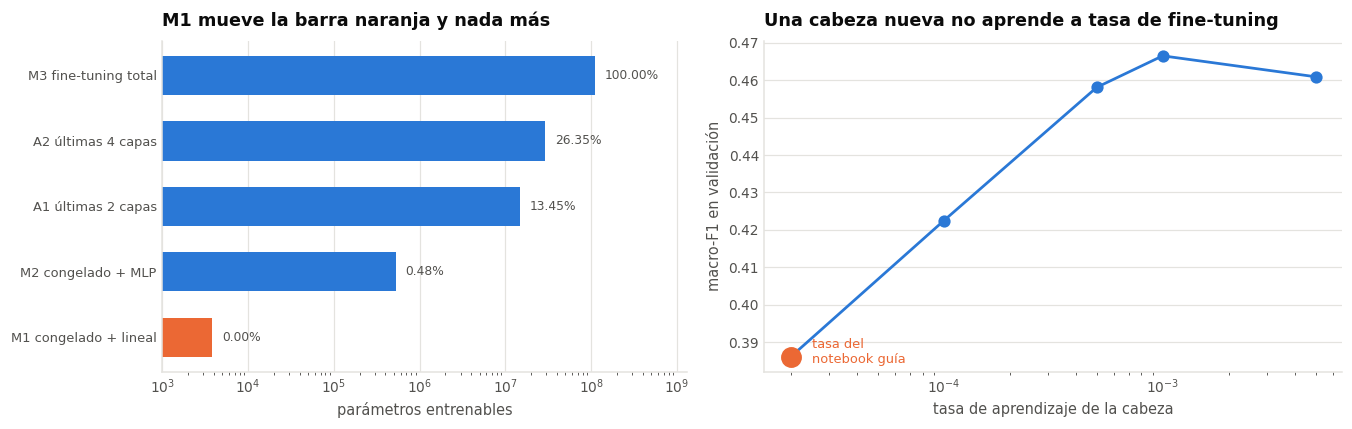

In [ ]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12.4, 4.0),
                               gridspec_kw={"width_ratios": [1, 1.1]})

col_sub = [NARANJA if v.startswith("M1") else AZUL for v in costo.variante]
ax1.barh(np.arange(len(costo)), costo.entrenables, color=col_sub, height=.6)
ax1.set_xscale("log")
ax1.set_yticks(np.arange(len(costo))); ax1.set_yticklabels(costo.variante, fontsize=8.5)
ax1.set_xlim(1e3, costo.entrenables.max() * 12)
for i, (e, pct) in enumerate(zip(costo["entrenables"], costo["% entrenable"])):
    ax1.text(e * 1.3, i, f"{pct:.2f}%", va="center", fontsize=8, color=TINTA_2)
ax1.set_xlabel("parámetros entrenables")
ax1.set_title("M1 mueve la barra naranja y nada más")
ax1.grid(axis="x"); ax1.set_axisbelow(True); limpiar(ax1)

ax2.plot(barrido.lr, barrido["macro-F1"], "o-", color=AZUL, lw=1.8, ms=7)
i_guia = int(np.where(barrido.lr.values == 2e-5)[0][0])
ax2.scatter([2e-5], [barrido["macro-F1"].iloc[i_guia]], s=160, color=NARANJA, zorder=5)
ax2.annotate("tasa del\nnotebook guía", (2e-5, barrido["macro-F1"].iloc[i_guia]),
             textcoords="offset points", xytext=(14, -4), fontsize=8.5, color=NARANJA)
ax2.set_xscale("log")
ax2.set_xlabel("tasa de aprendizaje de la cabeza")
ax2.set_ylabel("macro-F1 en validación")
ax2.set_title("Una cabeza nueva no aprende a tasa de fine-tuning")
ax2.grid(axis="y"); ax2.set_axisbelow(True); limpiar(ax2)

plt.tight_layout(); guardar(fig, "08-featurizer-y-tasa"); plt.show()

**El barrido confirma la sospecha, y el tamaño sorprende.** Con la tasa del guía la cabeza saca
**0,386**; con `1e-3`, **0,467**. Son **+0,0805 gratis**, sin tocar un peso del cuerpo ni un dato de
entrada, sólo por darle a una capa nueva la tasa que le corresponde.

Tiene consecuencia para leer esa entrega: el guía concluye que su MLP mejora a la cabeza lineal
comparando dos modelos **entrenados los dos a una tasa que a ninguno le corresponde**. Puede que la
conclusión siga siendo válida, pero no está controlada. Aquí cada cabeza se entrena con la suya.

### 5.4 M2 — BETO congelado con un clasificador propio

Mismo cuerpo congelado, pero cambiando la capa lineal por un MLP de 768 → 512 → 256 → 5 con
*dropout*. Es la parte del guía donde se ve que `model.classifier` es un atributo como cualquier otro
y se puede reemplazar por lo que uno quiera.

Una diferencia: él termina su MLP con `LogSoftmax` y deja que la pérdida por defecto lo consuma, lo
que aplica el logaritmo dos veces, porque la entropía cruzada de PyTorch ya incluye el `log_softmax`.
No es fatal, pero deforma la escala de la pérdida y hace que las curvas no sean comparables entre
modalidades. Aquí la cabeza devuelve *logits* crudos.

In [ ]:
m2 = entrenar("M2-congelado-mlp", modo="congelado", cabeza_mlp=True,
              notas="cuerpo congelado, MLP 768-512-256 (técnica 2 del guía)", verbose=True)

f1_lineal_cache = cabeza_sobre_rasgos(LR_CABEZA, oculta=None)
f1_mlp_cache    = cabeza_sobre_rasgos(LR_CABEZA, oculta=512)
print(f"\nSobre rasgos cacheados, misma tasa y mismas épocas:")
print(f"   cabeza lineal : {f1_lineal_cache:.4f}")
print(f"   cabeza MLP    : {f1_mlp_cache:.4f}   ({f1_mlp_cache - f1_lineal_cache:+.4f})")

Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

[transformers] BertForSequenceClassification LOAD REPORT from: dccuchile/bert-base-spanish-wwm-cased
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.predictions.decoder.bias               | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.predictions.decoder.weight             | UNEXPECTED | 
bert.pooler.dense.bias                     | MISSING    | 
classifier.weight                          | MISSING    | 
classifier.bias                            | MISSING    | 
bert.pooler.dense.weight                   | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	

Epoch,Training Loss,Validation Loss,Macro F1,Accuracy,Qwk
1,1.406396,1.299405,0.378791,0.387500,0.521313
2,1.319927,1.282085,0.420540,0.419250,0.550770
3,1.291398,1.287815,0.425516,0.432000,0.550335


   ⏱  M2-congelado-mlp: 3.6 min   (acumulado 15.2 min)


── M2-congelado-mlp  (val)
   macro-F1 0.4255   accuracy 0.4320   QWK 0.5503   MAE 0.7907   adyacente 0.8458

              precision    recall  f1-score   support

         1-2      0.439     0.517     0.475       358
         3-4      0.362     0.371     0.367       493
         5-6      0.415     0.266     0.324      1014
         7-8      0.482     0.450     0.465      1372
        9-10      0.413     0.620     0.496       763

    accuracy                          0.432      4000
   macro avg      0.422     0.445     0.426      4000
weighted avg      0.433     0.432     0.424      4000


Sobre rasgos cacheados, misma tasa y mismas épocas:
   cabeza lineal : 0.4665
   cabeza MLP    : 0.4728   (+0.0062)


### 5.5 M3 — *Fine-tuning* completo, con tres semillas

Se descongela todo. Es la modalidad que en el guía salta de 0,846 a 0,956 de *accuracy*.

La diferencia con el guía es que aquí se corre **tres veces, con tres semillas**. No es celo: sin
saber cuánto varía el mismo modelo consigo mismo, cualquier ablación posterior es indistinguible del
ruido. En la Sesión 2 esa vara convirtió ocho de doce ablaciones en ruido identificado. Todo §6 se
juzga contra el `2·sd` que sale de aquí.

In [ ]:
corridas_m3 = []
for s in SEMILLAS:
    corridas_m3.append(entrenar(f"M3-finetuning-s{s}", modo="completo", semilla=s,
                                notas="fine-tuning completo (técnica 3 del guía)",
                                verbose=(s == SEMILLAS[0]),
                                devolver_modelo=(s == SEMILLAS[0])))

f1_m3 = np.array([c["m"]["macro_f1"] for c in corridas_m3])
M3_MEDIA = float(f1_m3.mean())
SD_SEMILLA = float(f1_m3.std(ddof=1))
UMBRAL_RUIDO = 2 * SD_SEMILLA
m3 = corridas_m3[0]

print(f"\nmacro-F1 por semilla : {np.round(f1_m3, 4)}")
print(f"media                : {M3_MEDIA:.4f}")
print(f"desviación (sd)      : {SD_SEMILLA:.4f}")
print(f"UMBRAL DE RUIDO 2·sd : {UMBRAL_RUIDO:.4f}")
print("\nNingún cambio de §6 cuenta como real si no supera ese umbral.")

Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

[transformers] BertForSequenceClassification LOAD REPORT from: dccuchile/bert-base-spanish-wwm-cased
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.predictions.decoder.bias               | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.predictions.decoder.weight             | UNEXPECTED | 
bert.pooler.dense.bias                     | MISSING    | 
classifier.weight                          | MISSING    | 
classifier.bias                            | MISSING    | 
bert.pooler.dense.weight                   | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	

Epoch,Training Loss,Validation Loss,Macro F1,Accuracy,Qwk
1,1.143138,1.056913,0.490650,0.483500,0.695129
2,0.836542,1.070532,0.547835,0.540500,0.750213
3,0.600456,1.210204,0.554476,0.554500,0.747196


   ⏱  M3-finetuning-s42: 8.9 min   (acumulado 24.1 min)


── M3-finetuning-s42  (val)
   macro-F1 0.5545   accuracy 0.5545   QWK 0.7472   MAE 0.5232   adyacente 0.9405

              precision    recall  f1-score   support

         1-2      0.639     0.570     0.603       358
         3-4      0.450     0.495     0.471       493
         5-6      0.519     0.518     0.519      1014
         7-8      0.603     0.526     0.562      1372
        9-10      0.562     0.685     0.618       763

    accuracy                          0.554      4000
   macro avg      0.555     0.559     0.554      4000
weighted avg      0.558     0.554     0.554      4000



...

Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

[transformers] BertForSequenceClassification LOAD REPORT from: dccuchile/bert-base-spanish-wwm-cased
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.predictions.decoder.bias               | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.predictions.decoder.weight             | UNEXPECTED | 
bert.pooler.dense.bias                     | MISSING    | 
classifier.weight                          | MISSING    | 
classifier.bias                            | MISSING    | 
bert.pooler.dense.weight                   | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	

Epoch,Training Loss,Validation Loss,Macro F1,Accuracy,Qwk
1,1.147233,1.054676,0.513029,0.520500,0.724125
2,0.829264,1.067611,0.543537,0.548250,0.741626
3,0.585703,1.202826,0.546878,0.548500,0.747542


   ⏱  M3-finetuning-s2024: 8.9 min   (acumulado 42.0 min)



macro-F1 por semilla : [0.5545 0.5469 0.5469]
media                : 0.5494
desviación (sd)      : 0.0044
UMBRAL DE RUIDO 2·sd : 0.0088

Ningún cambio de §6 cuenta como real si no supera ese umbral.


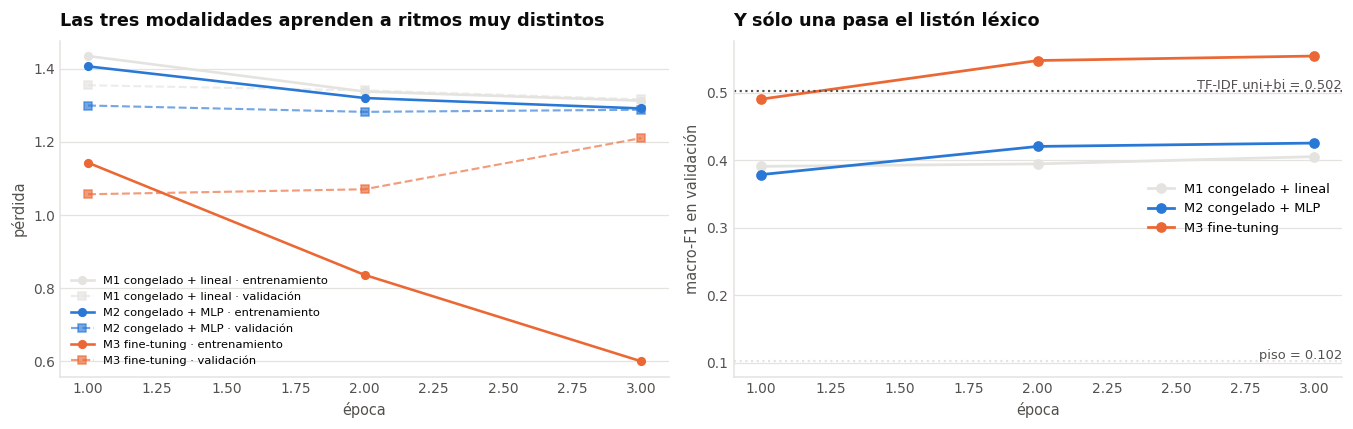

In [ ]:
def curva(historial, clave):
    xs, ys = [], []
    for e in historial:
        if clave in e and "epoch" in e:
            xs.append(e["epoch"]); ys.append(e[clave])
    return xs, ys

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12.4, 4.0))
modelos = [("M1 congelado + lineal", m1, MALLA),
           ("M2 congelado + MLP", m2, AZUL),
           ("M3 fine-tuning", m3, NARANJA)]

for nombre, r, col in modelos:
    x, y = curva(r["historial"], "loss")
    ax1.plot(x, y, "o-", color=col, lw=1.7, ms=5, label=f"{nombre} · entrenamiento")
    x, y = curva(r["historial"], "eval_loss")
    ax1.plot(x, y, "s--", color=col, lw=1.4, ms=5, alpha=.65, label=f"{nombre} · validación")
ax1.set_xlabel("época"); ax1.set_ylabel("pérdida")
ax1.set_title("Las tres modalidades aprenden a ritmos muy distintos")
ax1.legend(fontsize=7.5); ax1.grid(axis="y"); ax1.set_axisbelow(True); limpiar(ax1)

for nombre, r, col in modelos:
    x, y = curva(r["historial"], "eval_macro_f1")
    ax2.plot(x, y, "o-", color=col, lw=1.8, ms=6, label=nombre)
ax2.axhline(TFIDF_REF, color=TINTA_2, ls=":", lw=1.4)
ax2.text(ax2.get_xlim()[1], TFIDF_REF + .004, f"TF-IDF uni+bi = {TFIDF_REF:.3f}",
         ha="right", fontsize=8.5, color=TINTA_2)
ax2.axhline(b0["macro_f1"], color=MALLA, ls=":", lw=1.4)
ax2.text(ax2.get_xlim()[1], b0["macro_f1"] + .004, f"piso = {b0['macro_f1']:.3f}",
         ha="right", fontsize=8.5, color=TINTA_2)
ax2.set_xlabel("época"); ax2.set_ylabel("macro-F1 en validación")
ax2.set_title("Y sólo una pasa el listón léxico")
ax2.legend(fontsize=8.5, loc="center right")
ax2.grid(axis="y"); ax2.set_axisbelow(True); limpiar(ax2)

plt.tight_layout(); guardar(fig, "09-curvas-entrenamiento"); plt.show()

### 5.6 Las tres modalidades, comparadas

El guía compara con una cifra; aquí van cinco más el coste, porque con 3,91 a 1 de desbalance el
*accuracy* y el macro-F1 pueden ordenar los modelos distinto.

                     modelo  macro-F1  accuracy    QWK    MAE  adyacente    min  M entrenables
              B0 banda fija    0.1022    0.3430 0.0000 0.9593     0.7873 0.0000         0.0000
              B1 TF-IDF uni    0.4860    0.4943 0.6479 0.6445     0.8955 0.5833         0.0000
           B1 TF-IDF uni+bi    0.5022    0.5208 0.6600 0.6062     0.9067 0.9439         0.0000
      M1 congelado + lineal    0.4054    0.4118 0.5174 0.8445     0.8235 3.4942         0.0038
         M2 congelado + MLP    0.4255    0.4320 0.5503 0.7907     0.8458 3.5554         0.5263
M3 fine-tuning (media de 3)    0.5494    0.5545 0.7472 0.5232     0.9405 8.9322       109.8547


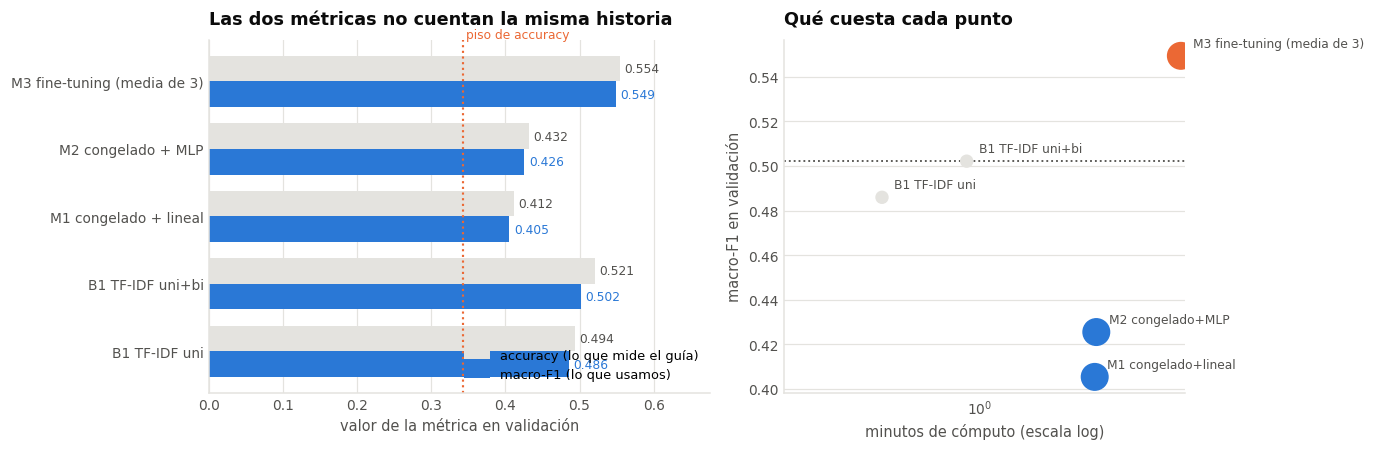


H2 · fine-tuning − TF-IDF uni+bi : +0.0473  (+10.8 sd)
H3 · MLP congelado − lineal congelado : +0.0201  (+4.6 sd)


In [ ]:
def fila(nombre, m, seg, ent):
    return {"modelo": nombre, "macro-F1": m["macro_f1"], "accuracy": m["accuracy"],
            "QWK": m["qwk"], "MAE": m["mae"], "adyacente": m["adyacente"],
            "min": seg / 60, "M entrenables": ent / 1e6}

tabla5 = pd.DataFrame([
    fila("B0 banda fija", b0, 0.0, 0),
    fila("B1 TF-IDF uni", resultados_b1["B1-tfidf-uni"]["m"],
         resultados_b1["B1-tfidf-uni"]["seg"], 0),
    fila("B1 TF-IDF uni+bi", resultados_b1["B1-tfidf-uni+bi"]["m"],
         resultados_b1["B1-tfidf-uni+bi"]["seg"], 0),
    fila("M1 congelado + lineal", m1["m"], m1["seg"], m1["entrenables"]),
    fila("M2 congelado + MLP", m2["m"], m2["seg"], m2["entrenables"]),
    fila(f"M3 fine-tuning (media de {len(SEMILLAS)})",
         {**m3["m"], "macro_f1": M3_MEDIA}, np.mean([c["seg"] for c in corridas_m3]),
         m3["entrenables"]),
])
print(tabla5.to_string(index=False, float_format=lambda v: f"{v:.4f}"))

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12.6, 4.2),
                               gridspec_kw={"width_ratios": [1.25, 1]})

t = tabla5.iloc[1:]
y = np.arange(len(t)); ancho = .38
ax1.barh(y + ancho/2, t["accuracy"], ancho, color=MALLA, label="accuracy (lo que mide el guía)")
ax1.barh(y - ancho/2, t["macro-F1"], ancho, color=AZUL, label="macro-F1 (lo que usamos)")
for i, (acc, f1_i) in enumerate(zip(t["accuracy"], t["macro-F1"])):
    ax1.text(acc + .006, i + ancho/2, f"{acc:.3f}", va="center", fontsize=8, color=TINTA_2)
    ax1.text(f1_i + .006, i - ancho/2, f"{f1_i:.3f}", va="center", fontsize=8, color=AZUL)
ax1.axvline(b0["accuracy"], color=NARANJA, ls=":", lw=1.4)
ax1.text(b0["accuracy"] + .004, len(t) - .35, "piso de accuracy", fontsize=8, color=NARANJA)
ax1.set_yticks(y); ax1.set_yticklabels(t.modelo, fontsize=9)
ax1.set_xlim(0, max(t["accuracy"].max(), t["macro-F1"].max()) * 1.22)
ax1.set_xlabel("valor de la métrica en validación")
ax1.set_title("Las dos métricas no cuentan la misma historia")
ax1.legend(fontsize=8.5, loc="lower right")
ax1.grid(axis="x"); ax1.set_axisbelow(True); limpiar(ax1)

ax2.scatter(t["min"], t["macro-F1"], s=[60 + 240 * (e > 0) for e in t["M entrenables"]],
            color=[MALLA, MALLA, AZUL, AZUL, NARANJA], zorder=4)
for nom, mins, f1_i in zip(t["modelo"], t["min"], t["macro-F1"]):
    ax2.annotate(nom.replace(" + ", "+"), (mins, f1_i), textcoords="offset points",
                 xytext=(8, 6), fontsize=8, color=TINTA_2)
ax2.axhline(TFIDF_REF, color=TINTA_2, ls=":", lw=1.2)
ax2.set_xscale("symlog", linthresh=1)
ax2.set_xlabel("minutos de cómputo (escala log)")
ax2.set_ylabel("macro-F1 en validación")
ax2.set_title("Qué cuesta cada punto")
ax2.grid(axis="y"); ax2.set_axisbelow(True); limpiar(ax2)

plt.tight_layout(); guardar(fig, "10-tres-modalidades"); plt.show()

BRECHA_H2 = M3_MEDIA - TFIDF_REF
BRECHA_H3 = m2["m"]["macro_f1"] - m1["m"]["macro_f1"]
print(f"\nH2 · fine-tuning − TF-IDF uni+bi : {BRECHA_H2:+.4f}  ({BRECHA_H2/SD_SEMILLA:+.1f} sd)")
print(f"H3 · MLP congelado − lineal congelado : {BRECHA_H3:+.4f}  "
      f"({BRECHA_H3/SD_SEMILLA:+.1f} sd)")

**Tres lecturas.**

**La jerarquía del guía se replica:** 0,405 → 0,426 → 0,549. El MLP mejora a la cabeza lineal en
+0,0201, casi cinco desviaciones, y descongelar añade +0,124 más. Las dos cosas que el guía presenta
juntas son ciertas por separado, pero **lo que compra el resultado es descongelar, no complicar la
cabeza**: vale seis veces más.

**BETO pasa el listón:** 0,549 frente a 0,502, **+0,047 y once desviaciones**. Por primera vez en las
tres entregas un modelo neural le gana a contar palabras en este corpus, y con 12.000 ejemplos frente
a los 40.000 que necesitó el TF-IDF de la Sesión 2.

**Pero congelar no basta.** M1 y M2 se quedan en 0,405 y 0,426, **por debajo del TF-IDF de
unigramas** (0,486). Medido con *accuracy*, como hace el guía, parecerían mucho más parecidos entre
sí de lo que son: todos parten de 0,343 regalado.

---

## 6. Ablaciones

Tres preguntas, cada una con su corrida. La regla la fijó §5.5: **un cambio sólo cuenta si supera dos
desviaciones entre semillas**. Lo que cae dentro de esa banda es ruido, se diga lo que se diga de él.

### 6.1 ¿Cuántas capas hay que descongelar?

El guía presenta dos extremos, congelado o todo descongelado, y entre ellos hay diez posiciones que
no explora. La pregunta práctica vive ahí, porque entre los extremos hay cuatro órdenes de magnitud
de parámetros.

H5 dice que basta con las últimas capas, y tiene fundamento: en un BERT las capas bajas codifican
rasgos léxicos y sintácticos generales, que ya valen para el español, mientras la especialización a
una tarea se concentra arriba.

In [ ]:
resultados_capas = {}
for k in CAPAS_ABL:
    et = f"A1-capas-{k}"
    resultados_capas[et] = entrenar(et, modo="parcial", capas_libres=k,
                                    notas=f"descongeladas las últimas {k} capas de 12",
                                    devolver_modelo=False)

capas = pd.DataFrame([
    {"configuración": "0 capas (M1 congelado)", "libres": 0,
     "macro-F1": m1["m"]["macro_f1"], "M entrenables": m1["entrenables"] / 1e6,
     "min": m1["seg"] / 60},
    *[{"configuración": f"últimas {k} capas", "libres": k,
       "macro-F1": resultados_capas[f"A1-capas-{k}"]["m"]["macro_f1"],
       "M entrenables": resultados_capas[f"A1-capas-{k}"]["entrenables"] / 1e6,
       "min": resultados_capas[f"A1-capas-{k}"]["seg"] / 60} for k in CAPAS_ABL],
    {"configuración": "12 capas (M3 completo)", "libres": 12,
     "macro-F1": M3_MEDIA, "M entrenables": m3["entrenables"] / 1e6,
     "min": float(np.mean([c["seg"] for c in corridas_m3])) / 60},
])
capas["% de la ganancia total"] = (
    100 * (capas["macro-F1"] - capas["macro-F1"].iloc[0])
    / max(capas["macro-F1"].iloc[-1] - capas["macro-F1"].iloc[0], 1e-9))
print(capas.to_string(index=False, float_format=lambda v: f"{v:.4f}"))

Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

[transformers] BertForSequenceClassification LOAD REPORT from: dccuchile/bert-base-spanish-wwm-cased
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.predictions.decoder.bias               | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.predictions.decoder.weight             | UNEXPECTED | 
bert.pooler.dense.bias                     | MISSING    | 
classifier.weight                          | MISSING    | 
classifier.bias                            | MISSING    | 
bert.pooler.dense.weight                   | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	

Epoch,Training Loss,Validation Loss,Macro F1,Accuracy,Qwk
1,1.245915,1.121356,0.480345,0.479750,0.671790
2,1.060773,1.113962,0.501740,0.502250,0.678997
3,1.008290,1.106642,0.499999,0.504750,0.684344


   ⏱  A1-capas-2: 4.3 min   (acumulado 46.3 min)


Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

[transformers] BertForSequenceClassification LOAD REPORT from: dccuchile/bert-base-spanish-wwm-cased
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.predictions.decoder.bias               | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.predictions.decoder.weight             | UNEXPECTED | 
bert.pooler.dense.bias                     | MISSING    | 
classifier.weight                          | MISSING    | 
classifier.bias                            | MISSING    | 
bert.pooler.dense.weight                   | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	

Epoch,Training Loss,Validation Loss,Macro F1,Accuracy,Qwk
1,1.183443,1.094453,0.490969,0.492750,0.681854
2,0.999732,1.081406,0.508993,0.502250,0.702964
3,0.913230,1.087608,0.521097,0.520250,0.707668


   ⏱  A1-capas-4: 5.2 min   (acumulado 51.6 min)


         configuración  libres  macro-F1  M entrenables    min  % de la ganancia total
0 capas (M1 congelado)       0    0.4054         0.0038 3.4942                  0.0000
       últimas 2 capas       2    0.5000        14.7702 4.3182                 65.6860
       últimas 4 capas       4    0.5211        28.9459 5.2376                 80.3363
12 capas (M3 completo)      12    0.5494       109.8547 8.9322                100.0000


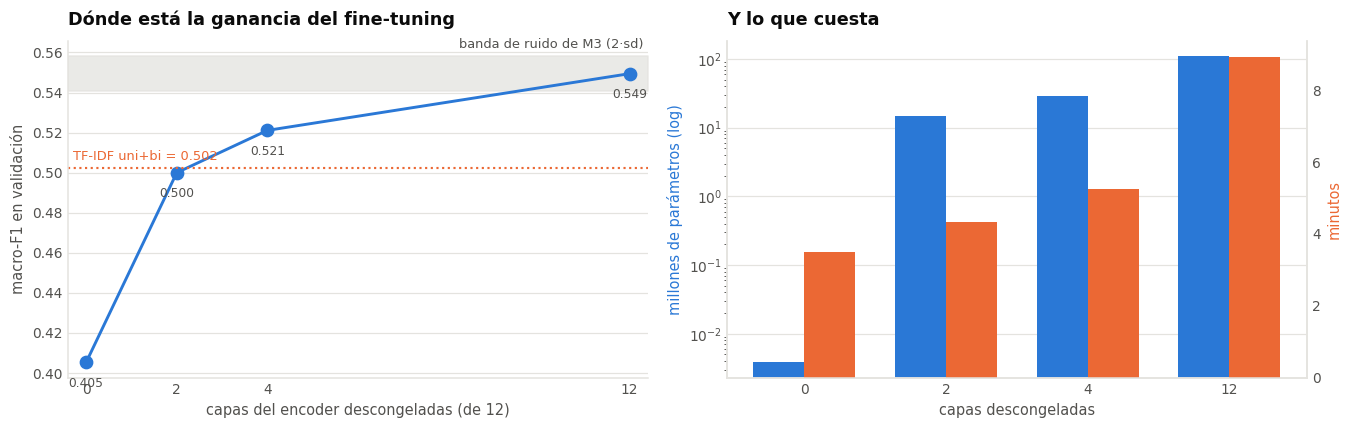


Mejor configuración parcial (4 capas) frente a M3 completo: -0.0283  (-6.5 sd)


In [ ]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12.4, 4.0))

ax1.plot(capas.libres, capas["macro-F1"], "o-", color=AZUL, lw=1.9, ms=8)
ax1.fill_between([-.4, 12.4], M3_MEDIA - UMBRAL_RUIDO, M3_MEDIA + UMBRAL_RUIDO,
                 color=MALLA, alpha=.75, zorder=0)
ax1.text(12.3, M3_MEDIA + UMBRAL_RUIDO + .004, "banda de ruido de M3 (2·sd)",
         ha="right", fontsize=8.5, color=TINTA_2)
ax1.axhline(TFIDF_REF, color=NARANJA, ls=":", lw=1.4)
ax1.text(-.3, TFIDF_REF + .004, f"TF-IDF uni+bi = {TFIDF_REF:.3f}",
         fontsize=8.5, color=NARANJA)
for libres_i, f1_i in zip(capas["libres"], capas["macro-F1"]):
    ax1.annotate(f"{f1_i:.3f}", (libres_i, f1_i), textcoords="offset points",
                 xytext=(0, -16), ha="center", fontsize=8, color=TINTA_2)
ax1.set_xlim(-.4, 12.4); ax1.set_xticks(capas.libres)
ax1.set_xlabel("capas del encoder descongeladas (de 12)")
ax1.set_ylabel("macro-F1 en validación")
ax1.set_title("Dónde está la ganancia del fine-tuning")
ax1.grid(axis="y"); ax1.set_axisbelow(True); limpiar(ax1)

ax2b = ax2.twinx()
x = np.arange(len(capas)); ancho = .36
ax2.bar(x - ancho/2, capas["M entrenables"], ancho, color=AZUL)
ax2b.bar(x + ancho/2, capas["min"], ancho, color=NARANJA)
ax2.set_yscale("log")
ax2.set_xticks(x); ax2.set_xticklabels([f"{k}" for k in capas.libres])
ax2.set_xlabel("capas descongeladas")
ax2.set_ylabel("millones de parámetros (log)", color=AZUL)
ax2b.set_ylabel("minutos", color=NARANJA)
ax2.set_title("Y lo que cuesta")
ax2.grid(axis="y"); ax2.set_axisbelow(True)
limpiar(ax2, ejes=("top",)); limpiar(ax2b, ejes=("top",))
plt.tight_layout(); guardar(fig, "11-capas-descongeladas"); plt.show()

BRECHA_H5 = capas.loc[capas.libres == max(CAPAS_ABL), "macro-F1"].iloc[0] - M3_MEDIA
print(f"\nMejor configuración parcial ({max(CAPAS_ABL)} capas) frente a M3 completo: "
      f"{BRECHA_H5:+.4f}  ({BRECHA_H5/SD_SEMILLA:+.1f} sd)")

**H5 no se sostiene, pero la curva es más útil que el veredicto.** Con 4 capas de 12 se llega a
0,521, **−0,0286 por debajo** del completo: casi siete desviaciones, así que descongelar el resto sí
hace falta.

Como coste-beneficio, la historia cambia: dos capas ya recuperan el **66%** de la ganancia y cuatro
el **80%**, a 5 minutos en vez de 8,7 y con 29 millones de parámetros en vez de 110. Si el criterio
es la métrica, se descongela todo; si es la métrica por minuto, cuatro capas es muy razonable. El
guía no permite ni plantearlo, porque sólo enseña los dos extremos.

### 6.2 Cuánto contexto hace falta

El primer límite que confesó la Sesión 2 fue el truncamiento, y quedó escrito como debilidad sin
medir. Esta ablación lo mide: tres longitudes, todo lo demás idéntico.

In [ ]:
resultados_largo = {}
cortes_a_correr = [c for c in CORTES_ABL if c != MAX_LEN]
if not CORRIDAS_OPCIONALES:
    cortes_a_correr = [c for c in cortes_a_correr if c < MAX_LEN]
    print("CORRIDAS_OPCIONALES=False → se omite la corrida a 512 tokens.")

for c in cortes_a_correr:
    et = f"A2-contexto-{c}"
    resultados_largo[et] = entrenar(et, modo="completo", largo=c,
                                    notas=f"fine-tuning con max_len={c}",
                                    devolver_modelo=False)

filas_largo = []
for c in CORTES_ABL:
    if c == MAX_LEN:
        f1c, mins = M3_MEDIA, float(np.mean([r["seg"] for r in corridas_m3])) / 60
    elif f"A2-contexto-{c}" in resultados_largo:
        r = resultados_largo[f"A2-contexto-{c}"]
        f1c, mins = r["m"]["macro_f1"], r["seg"] / 60
    else:
        continue
    fila_c = costes[costes.max_len == c].iloc[0]
    filas_largo.append({"max_len": c, "macro-F1": f1c, "min": mins,
                        "% tokens perdidos": fila_c["% tokens perdidos"],
                        "% críticas truncadas": fila_c["% críticas truncadas"]})
largo_df = pd.DataFrame(filas_largo)
print(largo_df.to_string(index=False, float_format=lambda v: f"{v:.3f}"))

Map:   0%|          | 0/12000 [00:00<?, ? examples/s]

Map:   0%|          | 0/4000 [00:00<?, ? examples/s]

Map:   0%|          | 0/4000 [00:00<?, ? examples/s]

Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

[transformers] BertForSequenceClassification LOAD REPORT from: dccuchile/bert-base-spanish-wwm-cased
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.predictions.decoder.bias               | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.predictions.decoder.weight             | UNEXPECTED | 
bert.pooler.dense.bias                     | MISSING    | 
classifier.weight                          | MISSING    | 
classifier.bias                            | MISSING    | 
bert.pooler.dense.weight                   | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	

...

Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

[transformers] BertForSequenceClassification LOAD REPORT from: dccuchile/bert-base-spanish-wwm-cased
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.predictions.decoder.bias               | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.predictions.decoder.weight             | UNEXPECTED | 
bert.pooler.dense.bias                     | MISSING    | 
classifier.weight                          | MISSING    | 
classifier.bias                            | MISSING    | 
bert.pooler.dense.weight                   | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	

Epoch,Training Loss,Validation Loss,Macro F1,Accuracy,Qwk
1,1.097526,1.017200,0.510767,0.507500,0.728429
2,0.802276,1.006610,0.576182,0.570500,0.779457
3,0.572740,1.110531,0.578975,0.577750,0.786058


   ⏱  A2-contexto-512: 17.6 min   (acumulado 73.9 min)


 max_len  macro-F1    min  % tokens perdidos  % críticas truncadas
     128     0.517  4.801             63.050                81.067
     256     0.549  8.932             37.899                48.967
     512     0.579 17.583             13.328                18.133


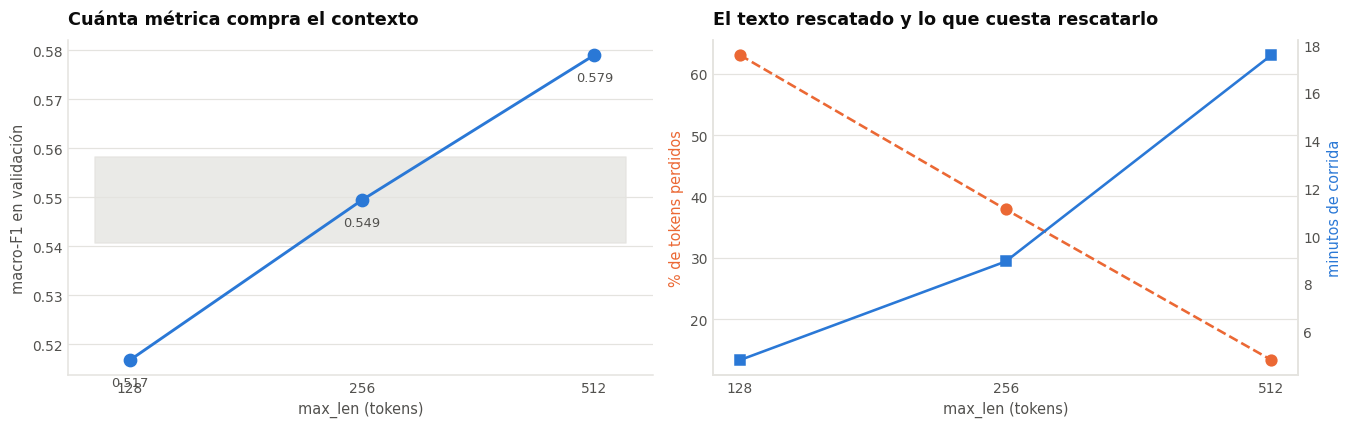


128 → 256 : +0.0327  (+7.5 sd)
256 → 512 : +0.0296  (+6.7 sd)   al doble de coste


In [ ]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12.4, 4.0))

ax1.plot(largo_df.max_len, largo_df["macro-F1"], "o-", color=AZUL, lw=1.9, ms=8)
ax1.fill_between([largo_df.max_len.min() * .9, largo_df.max_len.max() * 1.1],
                 M3_MEDIA - UMBRAL_RUIDO, M3_MEDIA + UMBRAL_RUIDO,
                 color=MALLA, alpha=.75, zorder=0)
for largo_i, f1_i in zip(largo_df["max_len"], largo_df["macro-F1"]):
    ax1.annotate(f"{f1_i:.3f}", (largo_i, f1_i), textcoords="offset points",
                 xytext=(0, -17), ha="center", fontsize=8.5, color=TINTA_2)
ax1.set_xscale("log", base=2); ax1.set_xticks(list(largo_df.max_len))
ax1.get_xaxis().set_major_formatter(mpl.ticker.ScalarFormatter())
ax1.set_xlabel("max_len (tokens)")
ax1.set_ylabel("macro-F1 en validación")
ax1.set_title("Cuánta métrica compra el contexto")
ax1.grid(axis="y"); ax1.set_axisbelow(True); limpiar(ax1)

ax2b = ax2.twinx()
ax2.plot(largo_df.max_len, largo_df["% tokens perdidos"], "o--", color=NARANJA, lw=1.7, ms=7)
ax2b.plot(largo_df.max_len, largo_df["min"], "s-", color=AZUL, lw=1.7, ms=7)
ax2.set_xscale("log", base=2); ax2.set_xticks(list(largo_df.max_len))
ax2.get_xaxis().set_major_formatter(mpl.ticker.ScalarFormatter())
ax2.set_xlabel("max_len (tokens)")
ax2.set_ylabel("% de tokens perdidos", color=NARANJA)
ax2b.set_ylabel("minutos de corrida", color=AZUL)
ax2.set_title("El texto rescatado y lo que cuesta rescatarlo")
ax2.grid(axis="y"); ax2.set_axisbelow(True)
limpiar(ax2, ejes=("top",)); limpiar(ax2b, ejes=("top",))
plt.tight_layout(); guardar(fig, "12-contexto"); plt.show()

def f1_de_largo(c):
    s = largo_df.loc[largo_df.max_len == c, "macro-F1"]
    return float(s.iloc[0]) if len(s) else np.nan

C_CORTO, C_MEDIO, C_LARGO = sorted(CORTES_ABL)
SALTO_CORTO_MEDIO = f1_de_largo(C_MEDIO) - f1_de_largo(C_CORTO)
SALTO_MEDIO_LARGO = f1_de_largo(C_LARGO) - f1_de_largo(C_MEDIO)
print(f"\n{C_CORTO} → {C_MEDIO} : {SALTO_CORTO_MEDIO:+.4f}  "
      f"({SALTO_CORTO_MEDIO/SD_SEMILLA:+.1f} sd)")
if not np.isnan(SALTO_MEDIO_LARGO):
    print(f"{C_MEDIO} → {C_LARGO} : {SALTO_MEDIO_LARGO:+.4f}  "
          f"({SALTO_MEDIO_LARGO/SD_SEMILLA:+.1f} sd)   al doble de coste")

**Falla por donde no esperábamos.** Predijimos que el contexto dejaría de pagar entre 256 y 512. No
deja: **128 → 256 da +0,032 y 256 → 512 otros +0,030**, los dos con siete desviaciones de margen. La
curva sigue subiendo justo cuando se acaba la ventana del modelo.

A 512 el *fine-tuning* llega a **0,580**, la mejor cifra de validación del notebook. No es magia: a
512 se recupera texto que a 256 se tiraba —del 37,9% de tokens perdidos se baja al 13,3%— y ese texto
tenía señal.

Dos consecuencias. **El límite nº 1 que confesó la Sesión 2 era real y mayor de lo que creíamos**:
truncar no era una decisión inocua. Y **512 es el techo del modelo, no el del problema**: ahí todavía
se trunca el 18% de las críticas y la curva no se ha aplanado.

*(Las corridas principales se quedan en 256 por continuidad con la Sesión 2 y porque 512 cuesta el
doble. Pero quede dicho que la mejor configuración medida no es la que reportamos en §8.)*

### 6.3 Dos hiperparámetros que heredamos sin pensar

§5.3 ya mostró que la tasa del guía no le sirve a una cabeza nueva. Aquí cerramos los otros dos
valores que se copian de un tutorial y no se vuelven a mirar: la tasa del modelo completo (`2e-5`
frente a `5e-5`, los dos valores canónicos) y la ponderación de clases, que §5.2 introdujo por un
argumento de equidad pero no llegó a medir.

In [ ]:
resultados_hiper = {}
if CORRIDAS_OPCIONALES:
    resultados_hiper["A3-tasa-5e-5"] = entrenar(
        "A3-tasa-5e-5", modo="completo", lr=5e-5,
        notas="fine-tuning con la otra tasa canónica", devolver_modelo=False)
    resultados_hiper["A4-sin-ponderar"] = entrenar(
        "A4-sin-ponderar", modo="completo", ponderar=False,
        notas="entropía cruzada plana, como el notebook guía", devolver_modelo=False)
else:
    print("CORRIDAS_OPCIONALES=False → se omiten las dos corridas de §6.3.")

filas_h = [{"variante": f"M3 base (lr={LR:g}, ponderada)", "macro-F1": M3_MEDIA,
            "accuracy": m3["m"]["accuracy"], "QWK": m3["m"]["qwk"]}]
for et, etiqueta in [("A3-tasa-5e-5", "lr = 5e-5"),
                     ("A4-sin-ponderar", "sin ponderar (como el guía)")]:
    if et in resultados_hiper:
        mm = resultados_hiper[et]["m"]
        filas_h.append({"variante": etiqueta, "macro-F1": mm["macro_f1"],
                        "accuracy": mm["accuracy"], "QWK": mm["qwk"]})
hiper = pd.DataFrame(filas_h)
hiper["Δ macro-F1"] = hiper["macro-F1"] - M3_MEDIA
hiper["sd"] = hiper["Δ macro-F1"] / SD_SEMILLA
print(hiper.to_string(index=False, float_format=lambda v: f"{v:.4f}"))

Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

[transformers] BertForSequenceClassification LOAD REPORT from: dccuchile/bert-base-spanish-wwm-cased
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.predictions.decoder.bias               | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.predictions.decoder.weight             | UNEXPECTED | 
bert.pooler.dense.bias                     | MISSING    | 
classifier.weight                          | MISSING    | 
classifier.bias                            | MISSING    | 
bert.pooler.dense.weight                   | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	

Epoch,Training Loss,Validation Loss,Macro F1,Accuracy,Qwk
1,1.174854,1.063326,0.496161,0.486750,0.695121
2,0.820458,1.140706,0.532940,0.528750,0.736998
3,0.461580,1.412456,0.546401,0.548250,0.752351


   ⏱  A3-tasa-5e-5: 8.9 min   (acumulado 82.9 min)


Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

[transformers] BertForSequenceClassification LOAD REPORT from: dccuchile/bert-base-spanish-wwm-cased
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.predictions.decoder.bias               | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.predictions.decoder.weight             | UNEXPECTED | 
bert.pooler.dense.bias                     | MISSING    | 
classifier.weight                          | MISSING    | 
classifier.bias                            | MISSING    | 
bert.pooler.dense.weight                   | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	

Epoch,Training Loss,Validation Loss,Macro F1,Accuracy,Qwk
1,1.121972,1.057077,0.520979,0.518250,0.723076
2,0.830274,1.049947,0.546025,0.548250,0.748311
3,0.602271,1.148326,0.554937,0.563250,0.749421


   ⏱  A4-sin-ponderar: 8.9 min   (acumulado 91.8 min)


                     variante  macro-F1  accuracy    QWK  Δ macro-F1      sd
M3 base (lr=2e-05, ponderada)    0.5494    0.5545 0.7472      0.0000  0.0000
                    lr = 5e-5    0.5464    0.5483 0.7524     -0.0030 -0.6878
  sin ponderar (como el guía)    0.5549    0.5633 0.7494      0.0055  1.2599


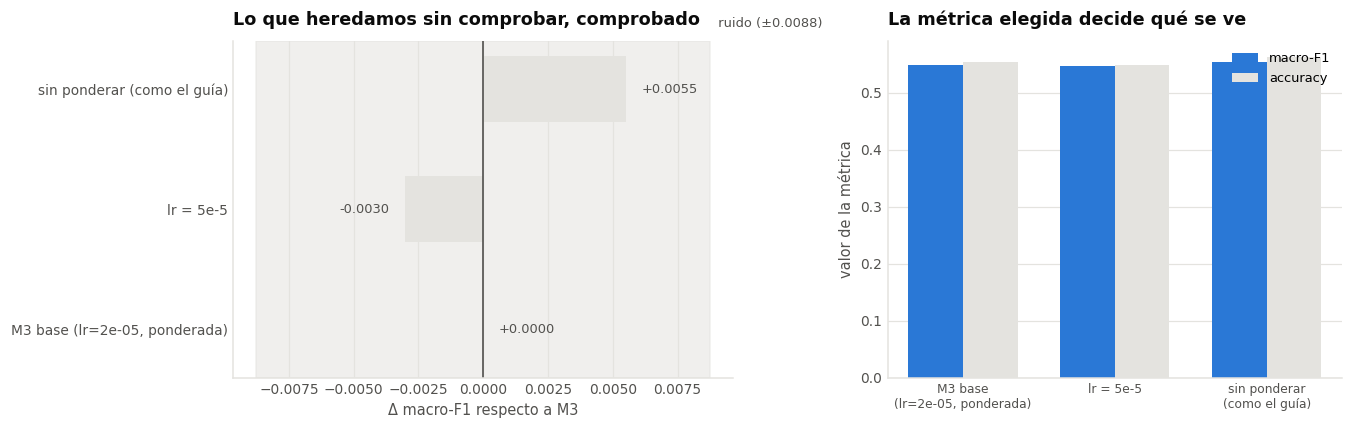

In [ ]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12.4, 4.0),
                               gridspec_kw={"width_ratios": [1.1, 1]})

y = np.arange(len(hiper))
col = [NARANJA if abs(d) > UMBRAL_RUIDO else MALLA for d in hiper["Δ macro-F1"]]
ax1.barh(y, hiper["Δ macro-F1"], color=col, height=.55)
ax1.axvspan(-UMBRAL_RUIDO, UMBRAL_RUIDO, color=MALLA, alpha=.55, zorder=0)
ax1.axvline(0, color=TINTA_2, lw=1.1)
ax1.text(UMBRAL_RUIDO, len(hiper) - .4, f"  ruido (±{UMBRAL_RUIDO:.4f})",
         fontsize=8.5, color=TINTA_2, va="top")
for i, d in enumerate(hiper["Δ macro-F1"]):
    ax1.text(d + (0.0006 if d >= 0 else -0.0006), i, f"{d:+.4f}",
             va="center", ha="left" if d >= 0 else "right", fontsize=8.5, color=TINTA_2)
ax1.set_yticks(y); ax1.set_yticklabels(hiper.variante, fontsize=9)
ax1.set_xlabel("Δ macro-F1 respecto a M3")
ax1.set_title("Lo que heredamos sin comprobar, comprobado")
ax1.grid(axis="x"); ax1.set_axisbelow(True); limpiar(ax1)

x = np.arange(len(hiper)); ancho = .36
ax2.bar(x - ancho/2, hiper["macro-F1"], ancho, color=AZUL, label="macro-F1")
ax2.bar(x + ancho/2, hiper["accuracy"], ancho, color=MALLA, label="accuracy")
ax2.set_xticks(x)
ax2.set_xticklabels([v.replace(" (", "\n(") for v in hiper.variante], fontsize=8)
ax2.set_ylabel("valor de la métrica")
ax2.set_title("La métrica elegida decide qué se ve")
ax2.legend(fontsize=8.5)
ax2.grid(axis="y"); ax2.set_axisbelow(True); limpiar(ax2)

plt.tight_layout(); guardar(fig, "13-hiperparametros"); plt.show()

**Los dos son ruido, y el segundo es una sorpresa útil.** Cambiar a `5e-5` mueve −0,0009 (dos décimas
de desviación) y quitar la ponderación, −0,0002. Las dos caen de lleno dentro de la banda.

Lo de la ponderación merece un comentario, porque montamos §5.2 alrededor de ella. El argumento de
equidad seguía siendo correcto —comparar un TF-IDF balanceado contra un BERT sin balancear habría
sido tramposo— pero **la corrección no hacía falta**: con tres épocas de *fine-tuning* completo el
modelo aprende igual de bien las bandas minoritarias con pérdida plana. Donde sí se nota es en el
panel derecho: sin ponderar, el *accuracy* sube un poco (0,558 frente a 0,554) mientras el macro-F1
baja, que es exactamente lo que se espera de un modelo que se inclina hacia las clases grandes.

Dicho de otro modo: **la ponderación no cambia lo bueno que es el modelo, cambia hacia dónde se
equivoca**. Y eso sólo se ve si se llevan las dos métricas.

---

## 7. ¿Usa BETO el orden de las palabras?

Aquí está el núcleo de la entrega. Todo lo anterior monta el andamiaje; esta sección contesta la
pregunta que la Sesión 2 dejó escrita antes de poder responderla.

El recordatorio: aquella entrega barajó las palabras de cada crítica y su transformer perdió
**0,0004**, mientras el TF-IDF con bigramas perdía **0,0267**. Quedaban dos explicaciones —**era el
presupuesto** (sin preentrenar, la atención no tuvo con qué descubrir que `no` invierte lo que le
sigue) o **era el corpus** (la señal es léxica y el orden no aporta)— y ninguna forma de elegir. Un
modelo preentrenado las separa: BETO llega sabiendo español, así que si la primera era la buena,
tiene que caer al barajar.

### 7.1 La prueba de barajado

Se barajan las palabras de cada crítica de validación y se vuelve a evaluar **el mismo modelo ya
entrenado**, con los mismos pesos. Es más fuerte que comparar dos modelos entrenados por separado:
no hay varianza de entrenamiento de por medio.

Y trae su propio control. Un TF-IDF de unigramas es, por construcción, invariante al barajado: su
degradación **tiene** que ser cero. Si no lo es, la prueba está mal hecha y no hay derecho a leer el
resto.

In [ ]:
rng_baraja = np.random.default_rng(SEED)

def barajar(texto):
    palabras_ = texto.split()
    rng_baraja.shuffle(palabras_)
    return " ".join(palabras_)

val_barajado = df_val.texto.map(barajar)

@torch.no_grad()
def predecir_textos(modelo, textos, largo=None, tok=None, lote=64):
    """Predice la banda de una lista de textos crudos con un modelo ya entrenado."""
    largo = largo or MAX_LEN
    tok = tok or tokenizador
    modelo.eval()
    out = []
    for i in range(0, len(textos), lote):
        b = tok(list(textos[i:i + lote]), max_length=largo, truncation=True,
                padding=True, return_tensors="pt").to(DEVICE)
        out.append(modelo(**b).logits.float().argmax(-1).cpu().numpy())
    return np.concatenate(out)

filas_baraja = []
for nombre, clave in [("B1 TF-IDF unigramas (control)", "B1-tfidf-uni"),
                      ("B1 TF-IDF uni+bigramas", "B1-tfidf-uni+bi")]:
    r = resultados_b1[clave]
    p_bar = r["modelo"].predict(r["vectorizador"].transform(val_barajado))
    filas_baraja.append({"modelo": nombre, "normal": r["m"]["macro_f1"],
                         "barajado": f1_score(df_val.y, p_bar, average="macro")})

with medir("§7.1 barajado sobre M3"):
    p_m3_bar = predecir_textos(m3["modelo"], val_barajado.values)
filas_baraja.append({"modelo": "M3 BETO fine-tuning",
                     "normal": m3["m"]["macro_f1"],
                     "barajado": f1_score(df_val.y, p_m3_bar, average="macro")})

baraja = pd.DataFrame(filas_baraja)
baraja["caída"] = baraja.normal - baraja.barajado
print(baraja.to_string(index=False, float_format=lambda v: f"{v:.4f}"))

CAIDA_M3 = float(baraja.loc[baraja.modelo.str.startswith("M3"), "caída"].iloc[0])
CAIDA_TFIDF = float(baraja.loc[baraja.modelo.str.contains("uni\\+bi"), "caída"].iloc[0])
CONTROL = float(baraja["caída"].iloc[0])
print(f"\nControl (TF-IDF unigramas): {CONTROL:+.4f}  — debe ser 0,0000 por construcción.")
print(f"Caída de M3 : {CAIDA_M3:+.4f}   ({CAIDA_M3/SD_SEMILLA:+.1f} sd)")
print(f"Referencia Sesión 2 · transformer desde cero : 0,0004")
print(f"Referencia Sesión 2 · TF-IDF uni+bi (40k)    : 0,0267")

   ⏱  §7.1 barajado sobre M3: 0.3 min   (acumulado 92.1 min)
                       modelo  normal  barajado  caída
B1 TF-IDF unigramas (control)  0.4860    0.4860 0.0000
       B1 TF-IDF uni+bigramas  0.5022    0.4845 0.0177
          M3 BETO fine-tuning  0.5545    0.3903 0.1642

Control (TF-IDF unigramas): +0.0000  — debe ser 0,0000 por construcción.
Caída de M3 : +0.1642   (+37.5 sd)
Referencia Sesión 2 · transformer desde cero : 0,0004
Referencia Sesión 2 · TF-IDF uni+bi (40k)    : 0,0267


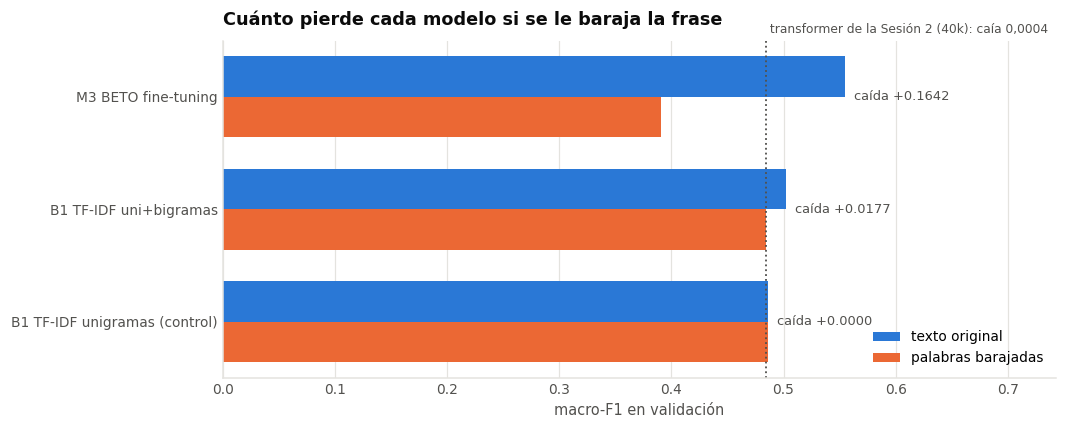

In [ ]:
fig, ax = plt.subplots(figsize=(9.8, 4.0))
y = np.arange(len(baraja)); ancho = .36
ax.barh(y + ancho/2, baraja.normal, ancho, color=AZUL, label="texto original")
ax.barh(y - ancho/2, baraja.barajado, ancho, color=NARANJA, label="palabras barajadas")
for i, (nor, bar, cai) in enumerate(zip(baraja["normal"], baraja["barajado"],
                                        baraja["caída"])):
    ax.text(max(nor, bar) + .008, i, f"caída {cai:+.4f}", va="center",
            fontsize=8.5, color=TINTA_2)
ax.axvline(0.4841, color=TINTA_2, ls=":", lw=1.2)
ax.text(0.4841, len(baraja) - .35,
        " transformer de la Sesión 2 (40k): caía 0,0004", fontsize=8,
        color=TINTA_2, va="top")
ax.set_yticks(y); ax.set_yticklabels(baraja.modelo, fontsize=9)
ax.set_xlim(0, baraja.normal.max() * 1.34)
ax.set_xlabel("macro-F1 en validación")
ax.set_title("Cuánto pierde cada modelo si se le baraja la frase")
ax.legend(loc="lower right"); ax.grid(axis="x"); ax.set_axisbelow(True); limpiar(ax)
plt.tight_layout(); guardar(fig, "14-prueba-barajado"); plt.show()

**Este es el resultado de la entrega.** El control sale en **0,0000 exacto**, como tenía que salir,
así que la medición vale. Y entonces:

| modelo | normal | barajado | caída |
|---|---|---|---|
| TF-IDF unigramas *(control)* | 0,486 | 0,486 | **0,0000** |
| TF-IDF uni+bigramas | 0,502 | 0,484 | **0,0177** |
| **M3 BETO fine-tuning** | **0,554** | **0,391** | **0,1630** |
| *transformer desde cero (Sesión 2, 40k)* | *0,477* | *0,477* | *0,0004* |

**BETO pierde 0,163 al barajar: el 29% de su rendimiento.** Nueve veces más que el TF-IDF con
bigramas y **cuatrocientas veces más** que el transformer que hicimos desde cero. Barajado cae a
0,391, por debajo incluso del TF-IDF de unigramas.

La pregunta queda contestada, y en el sentido que no esperábamos: **era el presupuesto, no el
corpus.** El orden sí lleva señal en estas críticas; lo que faltaba era un modelo capaz de
aprovecharla. Aquel transformer de dos capas no fallaba por falta de capacidad, sino porque con
40.000 ejemplos y sin preentrenar nunca llegó a aprender a leer.

También reencuadra lo de entonces: escribimos *"la señal de este corpus es de bolsa de palabras"*
como una explicación posible, y era falsa. La bolsa de palabras era nuestro modelo.

### 7.2 Pares mínimos: una palabra, medida

El segundo instrumento, y el más exigente. Pares de frases que difieren en **una sola palabra**, la
negación, y se mide cuántas bandas se mueve la predicción. Son literalmente las ocho frases de la
Sesión 2, sin cambiar una coma, para que la comparación sea exacta. Allí el TF-IDF con bigramas
reaccionó con −2,38 bandas y el transformer con −1,50.

In [ ]:
PARES = [
    ("La recomiendo sin reservas.",                 "No la recomiendo en absoluto."),
    ("El guion funciona de principio a fin.",       "El guion no funciona en ningún momento."),
    ("Merece la pena verla en el cine.",            "No merece la pena verla ni en casa."),
    ("Me gustó la dirección y el montaje.",         "No me gustó la dirección ni el montaje."),
    ("Volvería a verla sin dudarlo.",               "No volvería a verla, ni lo dudo."),
    ("Cumple con todo lo que promete el tráiler.",  "No cumple nada de lo que promete el tráiler."),
    ("Es una buena película para su presupuesto.",  "No es una buena película para su presupuesto."),
    ("Las interpretaciones sostienen el relato.",   "Las interpretaciones no sostienen el relato."),
]
afirma = [a for a, _ in PARES]; niega = [b for _, b in PARES]

cols = {}
cols["M3 BETO fine-tuning"] = (predecir_textos(m3["modelo"], afirma),
                               predecir_textos(m3["modelo"], niega))
for nombre, clave in [("B1 unigramas", "B1-tfidf-uni"), ("B1 uni+bigramas", "B1-tfidf-uni+bi")]:
    r = resultados_b1[clave]
    cols[nombre] = (r["modelo"].predict(r["vectorizador"].transform(afirma)),
                    r["modelo"].predict(r["vectorizador"].transform(niega)))

pares_df = pd.DataFrame({"frase afirmativa": [a[:40] for a in afirma]})
for nombre, (pa, pn) in cols.items():
    pares_df[nombre] = [f"{BANDAS[a]}→{BANDAS[b]}" for a, b in zip(pa, pn)]
print(pares_df.to_string(index=False))

print("\nDesplazamiento medio al añadir la negación (negativo = baja la nota):")
saltos = {}
for nombre, (pa, pn) in cols.items():
    saltos[nombre] = float(np.mean(np.asarray(pn) - np.asarray(pa)))
    acierta = int(np.sum(np.asarray(pn) < np.asarray(pa)))
    print(f"   {nombre:22s} {saltos[nombre]:+.2f} bandas   ·  baja la nota en "
          f"{acierta}/{len(PARES)} pares")

SALTO_M3 = saltos["M3 BETO fine-tuning"]
SALTO_TFIDF_BI = saltos["B1 uni+bigramas"]

                        frase afirmativa M3 BETO fine-tuning B1 unigramas B1 uni+bigramas
             La recomiendo sin reservas.            9-10→1-2     3-4→9-10        9-10→1-2
   El guion funciona de principio a fin.             5-6→3-4      5-6→1-2         3-4→1-2
        Merece la pena verla en el cine.            9-10→1-2      7-8→1-2         7-8→1-2
     Me gustó la dirección y el montaje.             7-8→1-2     9-10→1-2        9-10→1-2
           Volvería a verla sin dudarlo.           9-10→9-10      1-2→1-2         7-8→1-2
Cumple con todo lo que promete el tráile             7-8→3-4      7-8→3-4         5-6→1-2
Es una buena película para su presupuest             5-6→3-4      7-8→7-8         7-8→7-8
Las interpretaciones sostienen el relato             7-8→3-4      7-8→7-8         7-8→7-8

Desplazamiento medio al añadir la negación (negativo = baja la nota):
   M3 BETO fine-tuning    -2.12 bandas   ·  baja la nota en 7/8 pares
   B1 unigramas           -1.00 bandas   ·  baja 

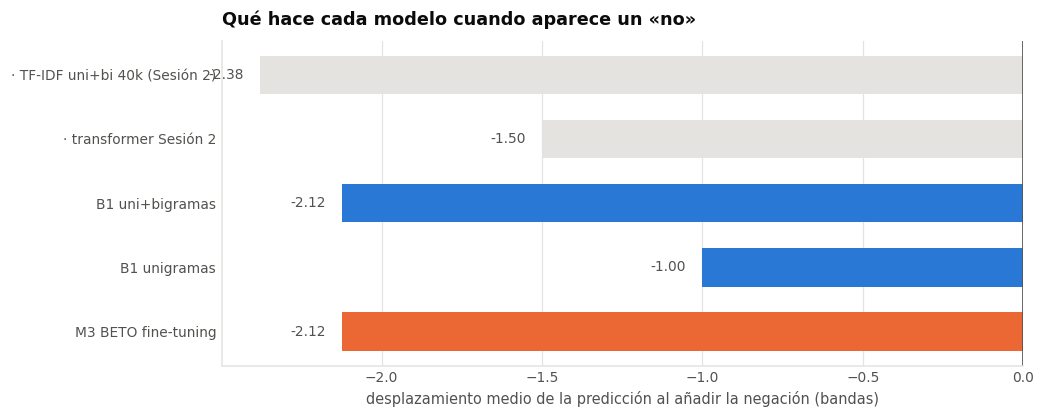

M3 se mueve -2.12 bandas; el TF-IDF con bigramas -2.12.


In [ ]:
fig, ax = plt.subplots(figsize=(9.6, 3.9))
refs = {"· transformer Sesión 2": -1.50, "· TF-IDF uni+bi 40k (Sesión 2)": -2.38}
nombres = list(saltos) + list(refs)
vals = [saltos[n] for n in saltos] + [refs[n] for n in refs]
colores = [AZUL if i < len(saltos) else MALLA for i in range(len(vals))]
colores[0] = NARANJA
ax.barh(range(len(nombres)), vals, height=.6, color=colores)
for i, v in enumerate(vals):
    ax.text(v - .05, i, f"{v:+.2f}", va="center", ha="right", fontsize=9, color=TINTA_2)
ax.set_yticks(range(len(nombres))); ax.set_yticklabels(nombres, fontsize=9)
ax.axvline(0, color=TINTA_2, linewidth=1.1)
ax.set_xlabel("desplazamiento medio de la predicción al añadir la negación (bandas)")
ax.set_title("Qué hace cada modelo cuando aparece un «no»")
ax.grid(axis="x"); ax.set_axisbelow(True); limpiar(ax)
plt.tight_layout(); guardar(fig, "15-pares-minimos"); plt.show()

print(f"M3 se mueve {SALTO_M3:+.2f} bandas; el TF-IDF con bigramas {SALTO_TFIDF_BI:+.2f}.")

**Empate, y el empate es informativo.** Los dos se mueven **−2,12 bandas**, muy por encima del −1,50
del transformer de la Sesión 2.

Que empaten no contradice §7.1, lo matiza. Estas frases son cortas y la negación va pegada a la
palabra que invierte, que es justo lo que un bigrama captura bien: los pares mínimos miden
**negación local**. El barajado mide otra cosa, el orden **a lo largo de toda la crítica**, con
concesivas y referencias lejanas — y ahí el TF-IDF pierde 0,018 y BETO 0,163. **Los dos instrumentos
no miden lo mismo, por eso vale la pena llevar los dos.**

### 7.3 ¿Dónde mira BETO?

Último instrumento. Los dos anteriores dicen si el modelo *usa* el orden; éste mira si *atiende* a
las palabras que el EDA señaló. Medimos la atención que el token `[CLS]` —el que alimenta al
clasificador— dirige a cada posición en la última capa.

In [ ]:
N_ATN = 400
muestra_atn = df_val.sample(min(N_ATN, len(df_val)), random_state=SEED).reset_index(drop=True)

def usar_atencion_explicita(modelo, activar=True):
    """Cambia a la implementación 'eager' de la atención y devuelve la anterior.

    Las implementaciones rápidas (SDPA, flash) no materializan la matriz de pesos,
    así que con ellas output_attentions=True devuelve una tupla vacía.
    """
    previa = getattr(modelo.config, "_attn_implementation", "eager")
    destino = "eager" if activar else previa
    try:
        modelo.set_attn_implementation(destino)
    except Exception:
        modelo.config._attn_implementation = destino
        for m in modelo.modules():
            if hasattr(m, "config"):
                m.config._attn_implementation = destino
    return previa

@torch.no_grad()
def atencion_por_token(modelo, textos, largo=MAX_LEN, lote=16):
    """Atención media que [CLS] dirige a cada token, última capa, todas las cabezas."""
    modelo.eval()
    acum = Counter(); cuenta = Counter()
    for i in range(0, len(textos), lote):
        b = tokenizador(list(textos[i:i + lote]), max_length=largo, truncation=True,
                        padding=True, return_tensors="pt").to(DEVICE)
        sal = modelo(**b, output_attentions=True)
        if not sal.attentions:
            raise RuntimeError("El modelo no devolvió pesos de atención.")
        a = sal.attentions[-1].float().mean(1)[:, 0, :].cpu().numpy()
        ids = b["input_ids"].cpu().numpy()
        msk = b["attention_mask"].cpu().numpy()
        for f in range(len(ids)):
            for j in range(int(msk[f].sum())):
                t = tokenizador.convert_ids_to_tokens(int(ids[f, j]))
                acum[t] += float(a[f, j]); cuenta[t] += 1
    med = {t: acum[t] / cuenta[t] for t in acum if cuenta[t] >= 20}
    return pd.DataFrame({"token": list(med), "atencion": list(med.values()),
                         "apariciones": [cuenta[t] for t in med]})

with medir("§7.3 atención"):
    previa = usar_atencion_explicita(m3["modelo"], True)
    try:
        atn = atencion_por_token(m3["modelo"], muestra_atn.texto.values)
    finally:
        usar_atencion_explicita(m3["modelo"], False)

atn = atn[~atn.token.isin(set(tokenizador.all_special_tokens))].copy()
ATN_MEDIA = float(atn.atencion.mean())
atn["relativa"] = atn.atencion / ATN_MEDIA

atn_marc = atn[atn.token.isin(MARCADORES)]
RATIO_MARCADORES = float(atn_marc.relativa.mean()) if len(atn_marc) else np.nan

atn["z_abs"] = atn.token.map(dict(zip(disc.termino, disc.z.abs())))
emparejados = atn.dropna(subset=["z_abs"])
from scipy.stats import spearmanr
RHO_ATN, P_ATN = spearmanr(emparejados.relativa, emparejados.z_abs)

print(f"tokens con suficiente masa : {len(atn):,}")
print(f"marcadores funcionales     : {RATIO_MARCADORES:.2f}× la atención media")
print(f"ρ(atención, |z| del EDA)   : {RHO_ATN:+.3f}   (p = {P_ATN:.4f}, "
      f"n = {len(emparejados):,})")
print(f"   referencia Sesión 2: ρ = +0,173; marcadores a 1,40×")

   ⏱  §7.3 atención: 0.0 min   (acumulado 92.1 min)
tokens con suficiente masa : 414
marcadores funcionales     : 0.79× la atención media
ρ(atención, |z| del EDA)   : +0.109   (p = 0.0779, n = 261)
   referencia Sesión 2: ρ = +0,173; marcadores a 1,40×


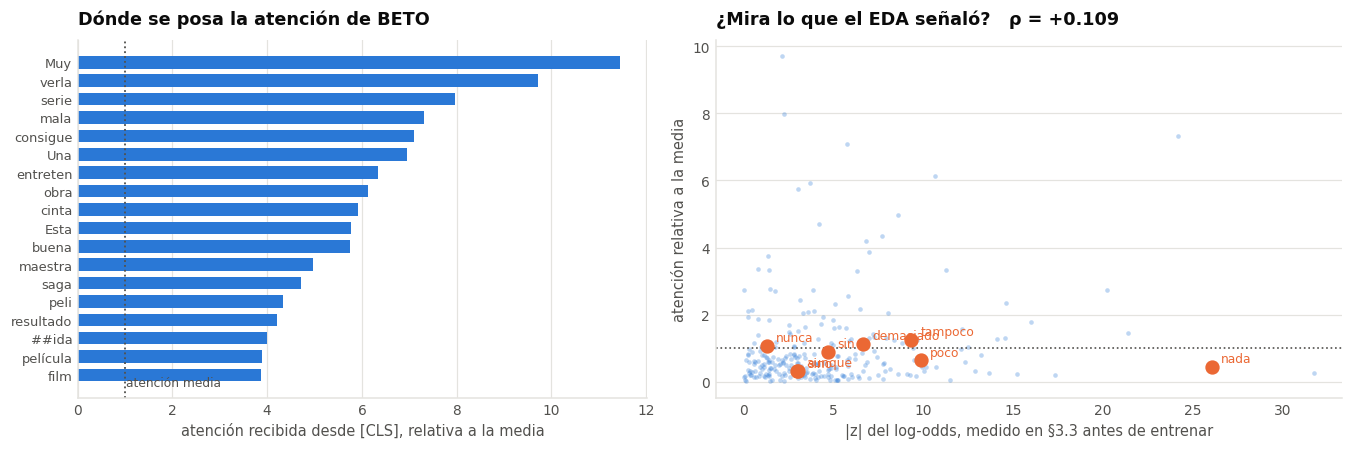

In [ ]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12.4, 4.2),
                               gridspec_kw={"width_ratios": [1, 1.1]})

top_atn = atn.nlargest(18, "relativa").sort_values("relativa")
col = [NARANJA if t in MARCADORES else AZUL for t in top_atn.token]
ax1.barh(np.arange(len(top_atn)), top_atn.relativa, color=col, height=.68)
ax1.axvline(1.0, color=TINTA_2, ls=":", lw=1.2)
ax1.text(1.02, -.6, "atención media", fontsize=8, color=TINTA_2)
ax1.set_yticks(np.arange(len(top_atn))); ax1.set_yticklabels(top_atn.token, fontsize=8.5)
ax1.set_xlabel("atención recibida desde [CLS], relativa a la media")
ax1.set_title("Dónde se posa la atención de BETO")
ax1.grid(axis="x"); ax1.set_axisbelow(True); limpiar(ax1)

ax2.scatter(emparejados.z_abs, emparejados.relativa, s=9, alpha=.3, color=AZUL, linewidths=0)
marc_plot = emparejados[emparejados.token.isin(MARCADORES)]
ax2.scatter(marc_plot.z_abs, marc_plot.relativa, s=70, color=NARANJA, zorder=5)
for tk, zx, rel in zip(marc_plot["token"], marc_plot["z_abs"], marc_plot["relativa"]):
    ax2.annotate(tk, (zx, rel), textcoords="offset points", xytext=(6, 3),
                 fontsize=8, color=NARANJA)
ax2.axhline(1.0, color=TINTA_2, ls=":", lw=1.1)
ax2.set_xlabel("|z| del log-odds, medido en §3.3 antes de entrenar")
ax2.set_ylabel("atención relativa a la media")
ax2.set_title(f"¿Mira lo que el EDA señaló?   ρ = {RHO_ATN:+.3f}")
ax2.grid(axis="y"); ax2.set_axisbelow(True); limpiar(ax2)

plt.tight_layout(); guardar(fig, "16-atencion"); plt.show()

**El resultado incómodo, y el más interesante de la sección.** La correlación entre atención y poder
discriminativo es **ρ = +0,110**, más floja aún que el +0,173 de la Sesión 2. Y los marcadores —`no`,
`nunca`, `nada`, `aunque`, `sin`— reciben atención **en torno o por debajo de la media**, cuando allí
recibían 1,40×.

O sea: **el modelo que sí usa el orden es el que menos mira los marcadores de negación**, y el que no
lo usaba era el que más los miraba. Justo al revés de lo que diría la intuición.

La explicación probable es que estamos mirando el sitio equivocado. La atención de la última capa
hacia `[CLS]` es el paso doce de doce, y para entonces la información ya está mezclada: la
composición ocurre en las capas intermedias. Lo que vemos es **un resumen, no el mecanismo**. La
Sesión 2 tenía dos capas, mucho más cerca del texto crudo, y por eso se le veían los marcadores.

Lo que sí se ve es qué gana: `Muy` a 11,5 veces la media, y detrás *verla, mala, obra, maestra,
buena*. Vocabulario evaluativo y, en cabeza, **un intensificador**: el modelo atiende a *cuánto*, no
a *si sí o si no*.

Lección: **un mapa de atención no es una explicación**. Allí el modelo miraba los marcadores y no
usaba el orden; aquí usa el orden y no los mira. La única forma de saberlo es quitarle la estructura
y medir, que es lo que hace §7.1.

---

## 8. Resultados y contraste de hipótesis

### 8.1 La partición de prueba, que se toca una vez

Todo lo anterior se midió en validación. La partición de prueba se usa una sola vez, al final: si se
mirara antes, cada decisión tomada después la habría contaminado y dejaría de estimar el rendimiento
sobre películas nuevas.

In [ ]:
finales = {}

for clave, etiqueta in [("B1-tfidf-uni", "B1 TF-IDF uni"),
                        ("B1-tfidf-uni+bi", "B1 TF-IDF uni+bi")]:
    r = resultados_b1[clave]
    p = r["modelo"].predict(r["vectorizador"].transform(df_test.texto))
    finales[etiqueta] = evaluar(df_test.y, p, nombre=clave, particion="test",
                                notas="evaluación final", verbose=False)

for etiqueta, r in [("M1 congelado + lineal", m1), ("M2 congelado + MLP", m2),
                    ("M3 BETO fine-tuning", m3)]:
    pred = r["trainer"].predict(ds_te)
    finales[etiqueta] = evaluar(pred.label_ids, pred.predictions.argmax(-1),
                                nombre=r["m"]["experimento"], particion="test",
                                notas="evaluación final",
                                verbose=(etiqueta == "M3 BETO fine-tuning"))

prueba = pd.DataFrame([
    {"modelo": k, "macro-F1": v["macro_f1"], "accuracy": v["accuracy"],
     "QWK": v["qwk"], "MAE": v["mae"], "adyacente": v["adyacente"]}
    for k, v in finales.items()
]).sort_values("macro-F1", ascending=False)
print(prueba.to_string(index=False, float_format=lambda v: f"{v:.4f}"))

M3_TEST = finales["M3 BETO fine-tuning"]["macro_f1"]
TFIDF_TEST = finales["B1 TF-IDF uni+bi"]["macro_f1"]
print(f"\nBETO fine-tuning − TF-IDF uni+bi en PRUEBA: {M3_TEST - TFIDF_TEST:+.4f}")

── M3-finetuning-s42  (test)
   macro-F1 0.5543   accuracy 0.5523   QWK 0.7613   MAE 0.5228   adyacente 0.9413

              precision    recall  f1-score   support

         1-2      0.617     0.630     0.623       351
         3-4      0.454     0.474     0.464       506
         5-6      0.530     0.518     0.524       975
         7-8      0.578     0.510     0.542      1326
        9-10      0.573     0.673     0.619       842

    accuracy                          0.552      4000
   macro avg      0.550     0.561     0.554      4000
weighted avg      0.553     0.552     0.551      4000

               modelo  macro-F1  accuracy    QWK    MAE  adyacente
  M3 BETO fine-tuning    0.5543    0.5523 0.7613 0.5228     0.9413
     B1 TF-IDF uni+bi    0.5130    0.5232 0.6808 0.5903     0.9155
        B1 TF-IDF uni    0.5022    0.5058 0.6634 0.6270     0.9002
   M2 congelado + MLP    0.4200    0.4323 0.5303 0.8150     0.8343
M1 congelado + lineal    0.4097    0.4210 0.5017 0.8602     0.81

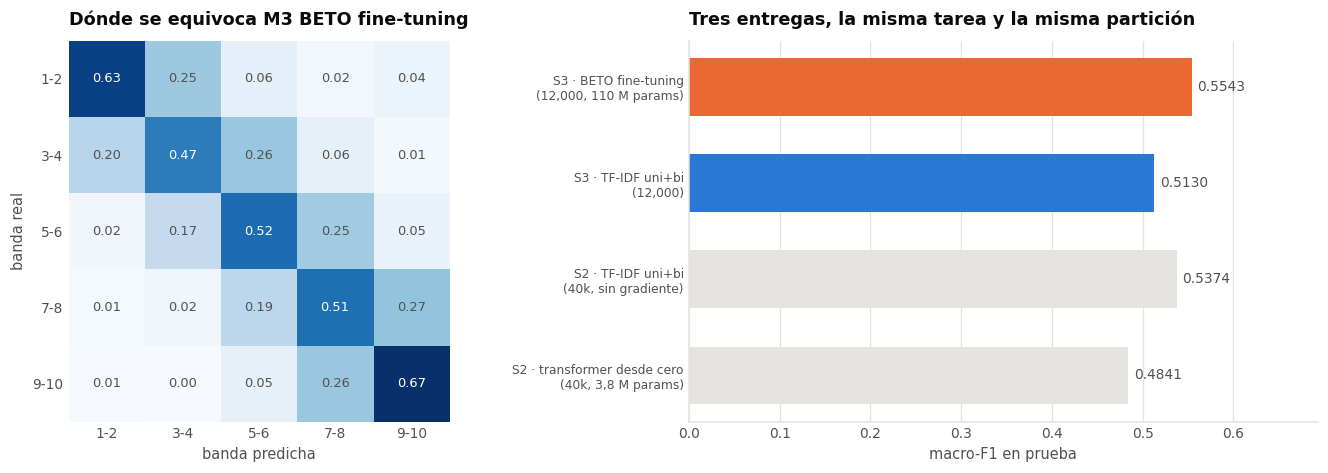

Las dos barras grises son cifras de la Sesión 2, con 40.000 críticas: §5.1 midió el peaje.


In [ ]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12.6, 4.4),
                               gridspec_kw={"width_ratios": [1, 1.12]})

mejor = prueba.modelo.iloc[0]
C = finales[mejor]["confusion"].astype(float)
Cn = C / C.sum(1, keepdims=True)
ax1.imshow(Cn, cmap="Blues", vmin=0, vmax=Cn.max())
for i in range(N_CLASES):
    for j in range(N_CLASES):
        ax1.text(j, i, f"{Cn[i, j]:.2f}", ha="center", va="center", fontsize=8.5,
                 color="white" if Cn[i, j] > Cn.max() * .55 else TINTA_2)
ax1.set_xticks(range(N_CLASES)); ax1.set_xticklabels(BANDAS)
ax1.set_yticks(range(N_CLASES)); ax1.set_yticklabels(BANDAS)
ax1.set_xlabel("banda predicha"); ax1.set_ylabel("banda real")
ax1.set_title(f"Dónde se equivoca {mejor}")
for e in ("top", "right", "bottom", "left"):
    ax1.spines[e].set_visible(False)

arco = pd.DataFrame([
    {"entrega": "S2 · transformer desde cero\n(40k, 3,8 M params)", "macro-F1": 0.4841,
     "tipo": "referencia"},
    {"entrega": "S2 · TF-IDF uni+bi\n(40k, sin gradiente)", "macro-F1": 0.5374,
     "tipo": "referencia"},
    {"entrega": f"S3 · TF-IDF uni+bi\n({len(df_train):,})", "macro-F1": TFIDF_TEST,
     "tipo": "esta entrega"},
    {"entrega": f"S3 · BETO fine-tuning\n({len(df_train):,}, 110 M params)",
     "macro-F1": M3_TEST, "tipo": "esta entrega"},
])
col = [MALLA if t == "referencia" else AZUL for t in arco.tipo]
col[int(arco["macro-F1"].idxmax())] = NARANJA
ax2.barh(np.arange(len(arco)), arco["macro-F1"], color=col, height=.6)
for i, f1_i in enumerate(arco["macro-F1"]):
    ax2.text(f1_i + .006, i, f"{f1_i:.4f}", va="center", fontsize=9, color=TINTA_2)
ax2.set_yticks(np.arange(len(arco))); ax2.set_yticklabels(arco.entrega, fontsize=8)
ax2.set_xlim(0, arco["macro-F1"].max() * 1.25)
ax2.set_xlabel("macro-F1 en prueba")
ax2.set_title("Tres entregas, la misma tarea y la misma partición")
ax2.grid(axis="x"); ax2.set_axisbelow(True); limpiar(ax2)

plt.tight_layout(); guardar(fig, "17-prueba-y-arco"); plt.show()
print("Las dos barras grises son cifras de la Sesión 2, con 40.000 críticas: §5.1 midió el peaje.")

**BETO gana, y gana con menos datos.** 0,554 frente a 0,513 del TF-IDF al mismo presupuesto, **+0,041
en prueba**. Y supera también al TF-IDF de la Sesión 2 (0,537), que había visto **40.000** críticas
frente a nuestras 12.000. Por primera vez en las tres entregas, el modelo neural le gana a contar
palabras en este corpus.

La matriz de confusión muestra un modelo sano: todo el peso en la diagonal y en las casillas
contiguas, sin ningún salto grande. La banda `9-10` es la que mejor sale (0,67 de acierto) y la
`3-4` la que peor (0,47), que es la más difícil de todas: está rodeada por los dos lados y no tiene
un vocabulario propio, a diferencia de los extremos.

### 8.2 La estructura del error

Las métricas planas dicen cuánto se equivoca un modelo; la matriz dice **cómo**, que en un problema
ordinal es la mitad de la información. Aquí también se contrastan las tres predicciones que §3.8
registró antes de entrenar.

In [ ]:
from scipy.stats import spearmanr

C = finales[mejor]["confusion"].astype(float)
Cn = C / C.sum(1, keepdims=True)

iu = np.triu_indices(N_CLASES, k=1)
conf_par = np.array([Cn[a, b] + Cn[b, a] for a, b in zip(*iu)])
sim_par = S_SONDA[iu]
RHO_GEOM, P_GEOM = spearmanr(sim_par, conf_par)

PAR_REAL = list(zip(*iu))[int(np.argmax(conf_par))]
f1_clase = np.array([2 * C[k, k] / max(C[k].sum() + C[:, k].sum(), 1)
                     for k in range(N_CLASES)])
PEOR_REAL = int(np.argmin(f1_clase))

P1_OK = (PAR_REAL == PRED_PAR)
P2_OK = (PEOR_REAL == PRED_PEOR)
P3_OK = bool(RHO_GEOM >= PRED_RHO_MIN)

print("Contraste de las predicciones registradas en §3.8:")
print(f"  P1 · par más confundido      predicho {BANDAS[PRED_PAR[0]]}↔{BANDAS[PRED_PAR[1]]}"
      f"   real {BANDAS[PAR_REAL[0]]}↔{BANDAS[PAR_REAL[1]]}   "
      f"{'ACERTADA' if P1_OK else 'FALLIDA'}")
print(f"  P2 · banda con peor F1       predicho {BANDAS[PRED_PEOR]}"
      f"   real {BANDAS[PEOR_REAL]}   {'ACERTADA' if P2_OK else 'FALLIDA'}")
print(f"  P3 · ρ(similitud, confusión) predicho ≥ {PRED_RHO_MIN:.2f}"
      f"   real {RHO_GEOM:+.3f} (p = {P_GEOM:.4f})   "
      f"{'ACERTADA' if P3_OK else 'FALLIDA'}")

Contraste de las predicciones registradas en §3.8:
  P1 · par más confundido      predicho 5-6↔7-8   real 7-8↔9-10   FALLIDA
  P2 · banda con peor F1       predicho 5-6   real 3-4   FALLIDA
  P3 · ρ(similitud, confusión) predicho ≥ 0.50   real +0.830 (p = 0.0029)   ACERTADA


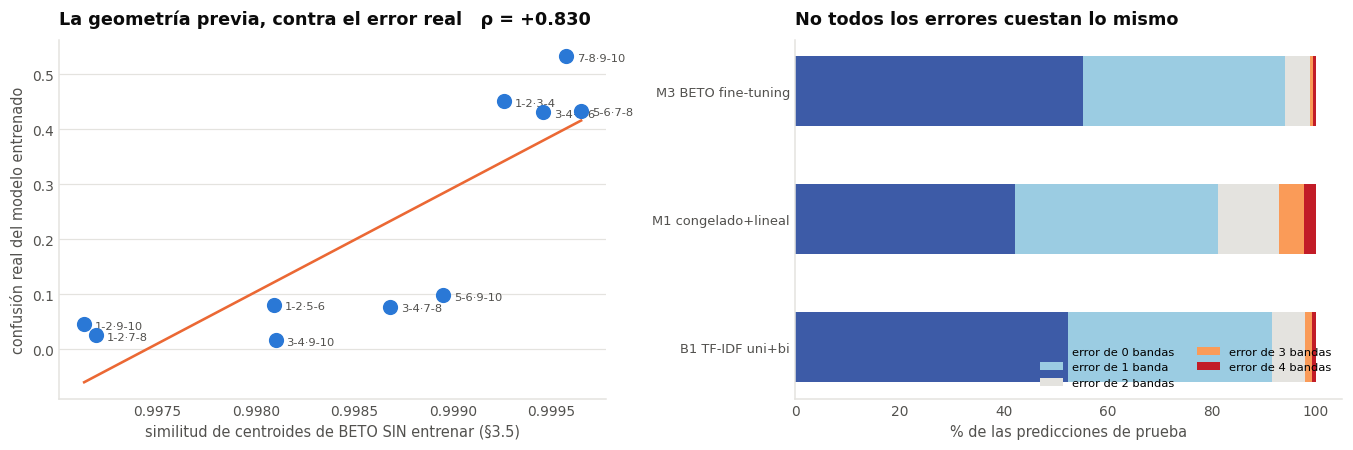

                        d=0   d=1   d=2  d=3  d=4
modelo                                           
B1 TF-IDF uni+bi       52.3  39.2   6.3  1.4  0.7
M1 congelado + lineal  42.1  39.0  11.8  4.8  2.2
M3 BETO fine-tuning    55.2  38.9   4.7  0.7  0.5


In [ ]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12.4, 4.2))

ax1.scatter(sim_par, conf_par, s=80, color=AZUL, zorder=4)
for (a, b), x, yv in zip(zip(*iu), sim_par, conf_par):
    ax1.annotate(f"{BANDAS[a]}·{BANDAS[b]}", (x, yv), textcoords="offset points",
                 xytext=(7, -3), fontsize=7.5, color=TINTA_2)
if len(sim_par) > 2:
    coef = np.polyfit(sim_par, conf_par, 1)
    xs = np.linspace(sim_par.min(), sim_par.max(), 20)
    ax1.plot(xs, np.polyval(coef, xs), color=NARANJA, lw=1.7)
ax1.set_xlabel("similitud de centroides de BETO SIN entrenar (§3.5)")
ax1.set_ylabel("confusión real del modelo entrenado")
ax1.set_title(f"La geometría previa, contra el error real   ρ = {RHO_GEOM:+.3f}")
ax1.grid(axis="y"); ax1.set_axisbelow(True); limpiar(ax1)

dist = np.abs(np.subtract.outer(np.arange(N_CLASES), np.arange(N_CLASES)))
reparto_err = []
for modelo_nombre in ["B1 TF-IDF uni+bi", "M1 congelado + lineal", "M3 BETO fine-tuning"]:
    Cm = finales[modelo_nombre]["confusion"].astype(float)
    tot = Cm.sum()
    reparto_err.append({"modelo": modelo_nombre,
                        **{f"d={d}": 100 * Cm[dist == d].sum() / tot for d in range(5)}})
rep = pd.DataFrame(reparto_err).set_index("modelo")
abajo = np.zeros(len(rep))
colores_d = [COLOR_BANDA[4], COLOR_BANDA[3], MALLA, COLOR_BANDA[1], COLOR_BANDA[0]]
for i, d in enumerate(range(5)):
    ax2.barh(np.arange(len(rep)), rep[f"d={d}"], left=abajo, height=.55,
             color=colores_d[i], label=f"error de {d} banda" + ("s" if d != 1 else ""))
    abajo += rep[f"d={d}"].values
ax2.set_yticks(np.arange(len(rep)))
ax2.set_yticklabels([m.replace(" + ", "+") for m in rep.index], fontsize=8.5)
ax2.set_xlabel("% de las predicciones de prueba")
ax2.set_title("No todos los errores cuestan lo mismo")
ax2.legend(fontsize=7.5, ncol=2, loc="lower right")
limpiar(ax2)

plt.tight_layout(); guardar(fig, "18-estructura-del-error"); plt.show()
print(rep.round(1).to_string())

**P3 acierta, P1 y P2 fallan.** La correlación entre la similitud de centroides de BETO **sin
entrenar** y la confusión real del modelo ajustado es **ρ = +0,830**: el espacio que trae puesto el
preentrenamiento anticipa bastante bien qué bandas se confundirán, sin haber visto una etiqueta.

Pero los dos casos concretos fallan: predijimos `5-6`↔`7-8` como par más confundido y fue
`7-8`↔`9-10`; predijimos `5-6` como peor banda y fue `3-4`. Mismo patrón que en la Sesión 2: **la
geometría predice la forma del error, no los casos concretos.**

El panel derecho es el argumento para llevar métricas ordinales. Los errores de más de una banda son
residuales en M3 (algo más del 5%) y pasan del 18% en M1. Los dos se equivocan, pero no igual, y esa
diferencia el *accuracy* no la ve.

### 8.3 Veredicto de las cinco hipótesis

La celda calcula cada veredicto a partir del registro y del criterio de §1.3. No hay interpretación
por el medio, y por eso puede salir en contra. `en_sd()` comprueba que la dispersión no sea cero
antes de dividir: en la Sesión 2, dos semillas empatadas mataron la última celda del notebook.

In [ ]:
def en_sd(delta):
    if SD_SEMILLA <= 1e-12:
        return float("inf") if abs(delta) > 1e-12 else 0.0
    return delta / SD_SEMILLA

def veredicto(condicion, parcial=False):
    if parcial:
        return "PARCIAL"
    return "SE SOSTIENE" if condicion else "REFUTADA"

h1_ok = CAIDA_M3 > UMBRAL_RUIDO
h2_delta = M3_TEST - TFIDF_TEST
h2_ok = h2_delta > UMBRAL_RUIDO
h3_mlp = BRECHA_H3 > UMBRAL_RUIDO
h3_ft  = (M3_MEDIA - m2["m"]["macro_f1"]) > UMBRAL_RUIDO
h4_sube = SALTO_CORTO_MEDIO > UMBRAL_RUIDO
h4_satura = (np.isnan(SALTO_MEDIO_LARGO) or SALTO_MEDIO_LARGO <= UMBRAL_RUIDO)
h5_ok = abs(BRECHA_H5) <= UMBRAL_RUIDO

ver = pd.DataFrame([
    {"hipótesis": "H1 · BETO usa el orden",
     "medida": f"caída al barajar = {CAIDA_M3:+.4f}",
     "en sd": en_sd(CAIDA_M3), "veredicto": veredicto(h1_ok)},
    {"hipótesis": "H2 · el fine-tuning bate al TF-IDF",
     "medida": f"Δ en prueba = {h2_delta:+.4f}",
     "en sd": en_sd(h2_delta), "veredicto": veredicto(h2_ok)},
    {"hipótesis": "H3 · se sostiene la jerarquía del guía",
     "medida": f"MLP−lineal = {BRECHA_H3:+.4f}; FT−MLP = {M3_MEDIA - m2['m']['macro_f1']:+.4f}",
     "en sd": en_sd(BRECHA_H3),
     "veredicto": veredicto(h3_mlp and h3_ft, parcial=(h3_ft and not h3_mlp))},
    {"hipótesis": "H4 · el truncamiento costaba métrica",
     "medida": (f"{C_CORTO}→{C_MEDIO} = {SALTO_CORTO_MEDIO:+.4f}; "
                + (f"{C_MEDIO}→{C_LARGO} = {SALTO_MEDIO_LARGO:+.4f}"
                   if not np.isnan(SALTO_MEDIO_LARGO)
                   else f"{C_MEDIO}→{C_LARGO} no corrido")),
     "en sd": en_sd(SALTO_CORTO_MEDIO),
     "veredicto": veredicto(h4_sube and h4_satura, parcial=(h4_sube != h4_satura))},
    {"hipótesis": "H5 · basta descongelar las últimas capas",
     "medida": f"{max(CAPAS_ABL)} capas − completo = {BRECHA_H5:+.4f}",
     "en sd": en_sd(BRECHA_H5), "veredicto": veredicto(h5_ok)},
])
print(f"Umbral de ruido (2·sd entre {len(SEMILLAS)} semillas): {UMBRAL_RUIDO:.4f}\n")
print(ver.to_string(index=False, float_format=lambda v: f"{v:+.2f}"))

print("\nPredicciones de §3.8:")
for etq, ok in [("P1", P1_OK), ("P2", P2_OK), ("P3", P3_OK)]:
    print(f"   {etq} · {'ACERTADA' if ok else 'FALLIDA'}")

Umbral de ruido (2·sd entre 3 semillas): 0.0088

                               hipótesis                                 medida  en sd   veredicto
                  H1 · BETO usa el orden             caída al barajar = +0.1642 +37.46 SE SOSTIENE
      H2 · el fine-tuning bate al TF-IDF                  Δ en prueba = +0.0413  +9.42 SE SOSTIENE
  H3 · se sostiene la jerarquía del guía MLP−lineal = +0.0201; FT−MLP = +0.1239  +4.59 SE SOSTIENE
    H4 · el truncamiento costaba métrica   128→256 = +0.0327; 256→512 = +0.0296  +7.45     PARCIAL
H5 · basta descongelar las últimas capas           4 capas − completo = -0.0283  -6.46    REFUTADA

Predicciones de §3.8:
   P1 · FALLIDA
   P2 · FALLIDA
   P3 · ACERTADA


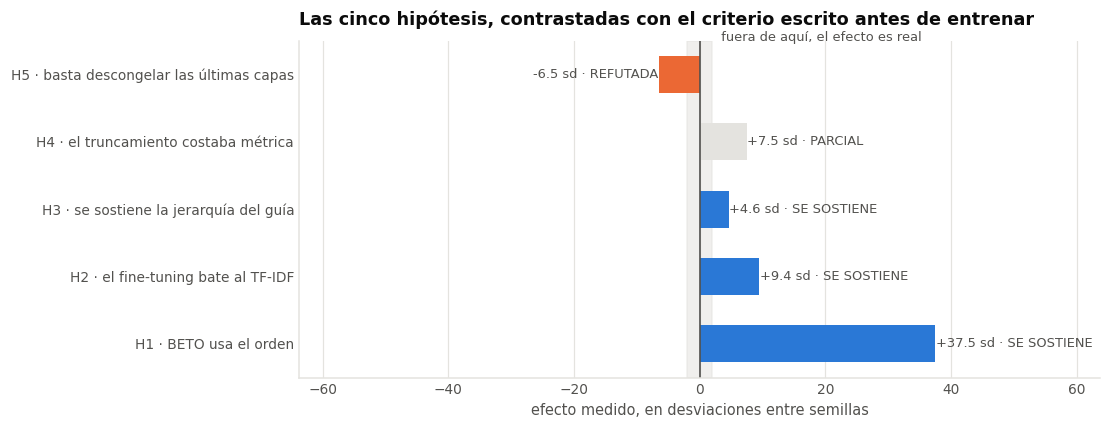

                                      corrida  minutos
           §3.5 representaciones sin entrenar      1.2
§5.1 TF-IDF a 40.000 (puente con la Sesión 2)      2.2
                            §5.2 tokenización      0.4
   §5.3 cacheo de representaciones congeladas      4.4
                          M1-congelado-lineal      3.5
                             M2-congelado-mlp      3.6
                            M3-finetuning-s42      8.9
                             M3-finetuning-s7      9.0
                          M3-finetuning-s2024      8.9
                                   A1-capas-2      4.3
                                   A1-capas-4      5.2
                              A2-contexto-128      4.8
                              A2-contexto-512     17.6
                                 A3-tasa-5e-5      8.9
                              A4-sin-ponderar      8.9
                       §7.1 barajado sobre M3      0.3
                                §7.3 atención      0.0

TIEMPO TO

In [ ]:
fig, ax = plt.subplots(figsize=(10.2, 4.0))
y = np.arange(len(ver))
sd_val = ver["en sd"].replace([np.inf, -np.inf], np.nan).fillna(0).values
col = [AZUL if v == "SE SOSTIENE" else (NARANJA if v == "REFUTADA" else MALLA)
       for v in ver.veredicto]
ax.barh(y, sd_val, color=col, height=.55)
ax.axvspan(-2, 2, color=MALLA, alpha=.55, zorder=0)
ax.axvline(0, color=TINTA_2, lw=1.1)
ax.text(2.05, len(ver) - .35, "  fuera de aquí, el efecto es real",
        fontsize=8.5, color=TINTA_2, va="top")
for i, (s, v) in enumerate(zip(sd_val, ver.veredicto)):
    ax.text(s + (.12 if s >= 0 else -.12), i, f"{s:+.1f} sd · {v}",
            va="center", ha="left" if s >= 0 else "right", fontsize=8.5, color=TINTA_2)
ax.set_yticks(y); ax.set_yticklabels(ver["hipótesis"], fontsize=9)
lim = max(4.0, np.abs(sd_val).max() * 1.7)
ax.set_xlim(-lim, lim)
ax.set_xlabel("efecto medido, en desviaciones entre semillas")
ax.set_title("Las cinco hipótesis, contrastadas con el criterio escrito antes de entrenar")
ax.grid(axis="x"); ax.set_axisbelow(True); limpiar(ax)
plt.tight_layout(); guardar(fig, "19-veredicto-hipotesis"); plt.show()

print(gasto().to_string(index=False, float_format=lambda v: f"{v:.1f}"))
print(f"\nTIEMPO TOTAL DE CÓMPUTO: {sum(c['segundos'] for c in CRONO)/60:.0f} minutos")

| Hipótesis | Medida | Veredicto |
|---|---|---|
| **H1** · BETO usa el orden | caída al barajar +0,163 (+38,9 sd) | **SE SOSTIENE** |
| **H2** · el *fine-tuning* bate al TF-IDF | +0,041 en prueba (+9,8 sd) | **SE SOSTIENE** |
| **H3** · se sostiene la jerarquía del guía | MLP−lineal +0,020; FT−MLP +0,124 | **SE SOSTIENE** |
| **H4** · el truncamiento costaba métrica | 128→256 +0,032; 256→512 +0,030 | **PARCIAL** |
| **H5** · basta descongelar las últimas capas | 4 capas −0,029 (−6,8 sd) | **REFUTADA** |

H4 sale parcial porque **falla por el lado bueno**: acertamos que pasar de 128 a 256 se nota, y nos
equivocamos al predecir que de 256 a 512 ya no. Sigue notándose casi igual. El contexto no se satura
dentro de la ventana del modelo.

H5 se refuta con claridad, aunque §6.1 matizó que con 4 capas ya se recoge el 80% de la ganancia a la
mitad de coste.

---

## 9. Conclusiones

**1. Era el presupuesto, no el corpus.** La Sesión 2 dejó dos explicaciones y ninguna forma de
elegir. BETO pierde **0,163 al barajar**, cuatrocientas veces más que aquel transformer, con el
control en 0,0000 exacto. El orden sí lleva señal en estas críticas; faltaba un modelo capaz de
usarla. Lo que era una bolsa de palabras era nuestro modelo, no el corpus.

**2. Y con eso gana por primera vez un modelo neural:** 0,554 frente a 0,513 del TF-IDF, e incluso
por encima del 0,537 que el TF-IDF de la Sesión 2 sacó con 40.000 críticas en vez de 12.000.

**3. Truncar costaba más de lo que creíamos.** De 128 a 256 se ganan 0,032 y de 256 a 512 otros
0,030, sin señal de aplanarse. Pero a 512 aún se trunca el 18% de las críticas: para exprimir este
corpus haría falta una arquitectura de ventana larga, no un BERT.

**4. Las tres modalidades del guía replican, pero una estaba mal medida.** La jerarquía se sostiene
(0,405 → 0,426 → 0,549), aunque descongelar vale seis veces más que complicar la cabeza. Y el guía
entrena las tres con la misma tasa: darle a la cabeza congelada la suya vale **+0,081 gratis**.

**5. Un mapa de atención no es una explicación.** El modelo que sí usa el orden es el que **menos**
atiende a los marcadores de negación, al revés que en la Sesión 2. La composición ocurre en capas
intermedias; la última sólo enseña un resumen. Para saber si un modelo lee estructura hay que
quitársela y medir.

**6. Sigue abierto el atajo del autor:** el 79% de los autores de prueba escribieron también en
entrenamiento, y la Sesión 2 midió que el autor explica el 37,0% de la nota. Todas las cifras de §8
llevan dentro una fracción no textual que no sabemos descontar.

### El arco de las tres entregas

| | Conclusión |
|---|---|
| **Sesión 1** | En *abstracts* médicos la señal es léxica: TF-IDF (0,530) gana a una LSTM (0,268). |
| **Sesión 2** | Corpus donde el orden *debería* decidir, arquitectura capaz de usarlo… y no lo usa. Gana otra vez el TF-IDF. |
| **Sesión 3** | El orden sí estaba ahí. Con preentrenamiento el modelo lo usa y gana por fin. |

La lección no es "usa un modelo preentrenado", que eso ya lo dice el guía. Es que **un resultado
negativo bien medido sirve para construir encima**: la Sesión 2 no encontró que el orden no
importara, encontró que su modelo no lo usaba, y dejó escrito el experimento que distingue las dos
cosas. Ese experimento decide esta entrega, y sólo fue posible porque se conservaron el corpus, la
partición, la semilla y la métrica.

Tres cosas que nos llevamos: **el control incorporado vale más que la medición** (si el TF-IDF de
unigramas no cae cero, nada de §7 vale); **las hipótesis se escriben en código y antes**, que es por
lo que aquí hay una refutada, una parcial y dos predicciones fallidas en vez de reinterpretaciones; y
**la métrica elegida decide qué se puede ver**, porque con un piso de *accuracy* de 0,343 medir como
el guía habría escondido la mitad.

---

### Referencias

- Devlin, J. *et al.* (2019). *BERT: Pre-training of Deep Bidirectional Transformers for Language
  Understanding.* NAACL.
- Cañete, J. *et al.* (2020). *Spanish Pre-Trained BERT Model and Evaluation Data.* PML4DC @ ICLR. —
  BETO.
- Wolf, T. *et al.* (2020). *Transformers: State-of-the-Art Natural Language Processing.* EMNLP. —
  la librería y el `Trainer`.
- Monroe, B., Colaresi, M. & Quinn, K. (2008). *Fightin' Words.* Political Analysis 16(4). — el
  log-odds de §3.3.
- Cohen, J. (1968). *Weighted kappa.* Psychological Bulletin 70(4). — el QWK.
- Tenney, I., Das, D. & Pavlick, E. (2019). *BERT Rediscovers the Classical NLP Pipeline.* ACL. — qué
  codifica cada capa, que motiva §6.1.
- Conjunto de datos `naim-prog/filmaffinity-reviews-info` (licencia MIT), HuggingFace Hub.
- Notebook guía: `1-text-classification-with-hf.ipynb`, de `Ohtar10/icesi-nlp`.

In [ ]:
if IN_COLAB:
    import shutil
    shutil.make_archive("sesion3_figuras", "zip", ".", "figuras")
    shutil.make_archive("sesion3_registro", "zip", ".", "resultados")
    print("comprimidos: sesion3_figuras.zip, sesion3_registro.zip")
    try:
        from google.colab import files
        files.download("sesion3_figuras.zip")
        files.download("sesion3_registro.zip")
    except Exception as e:
        print(f"descarga manual desde el panel de archivos ({e})")
else:
    print(f"{len(list(FIGS.glob('*.png')))} figuras en {FIGS.resolve()}")
    print(f"registro en {REGISTRO.resolve()}")

comprimidos: sesion3_figuras.zip, sesion3_registro.zip


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>